<a href="https://colab.research.google.com/github/shunazhai-hue/ebp-medical/blob/main/%E2%80%9C%E2%80%9CThe_second_manuscript_ipynb%E2%80%9D5.25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== MyDrive folders ===
  2026_lecture
  Colab Notebooks
  Google AI Studio
  SL
  The  second manuscript-zhaishuna
  book-professor Choi
  ebp-medical_1
  jsn_sea
  ky
  medical_big
  output
  pil
  tm
  xy

✓ Auto-detected: /content/drive/MyDrive/The  second manuscript-zhaishuna

📂 Input : /content/drive/MyDrive/The  second manuscript-zhaishuna/input
📂 Output: /content/drive/MyDrive/The  second manuscript-zhaishuna/output
📊 Excel : /content/drive/MyDrive/The  second manuscript-zhaishuna/input/NHANES database revison.xlsx

=== Input files ===
  NHANES database revison.xlsx
  manuscript-methods and results.docx
n=7,231, DM=1,418 (19.6%)
Train=5,061, Test=2,170, Resampled=6,017
Features: 24 (Metabolic syndrome excluded)

Model                        AUC    Acc     F1   Prec    Rec
----------------------------------------------------------
Gradient Boosting    

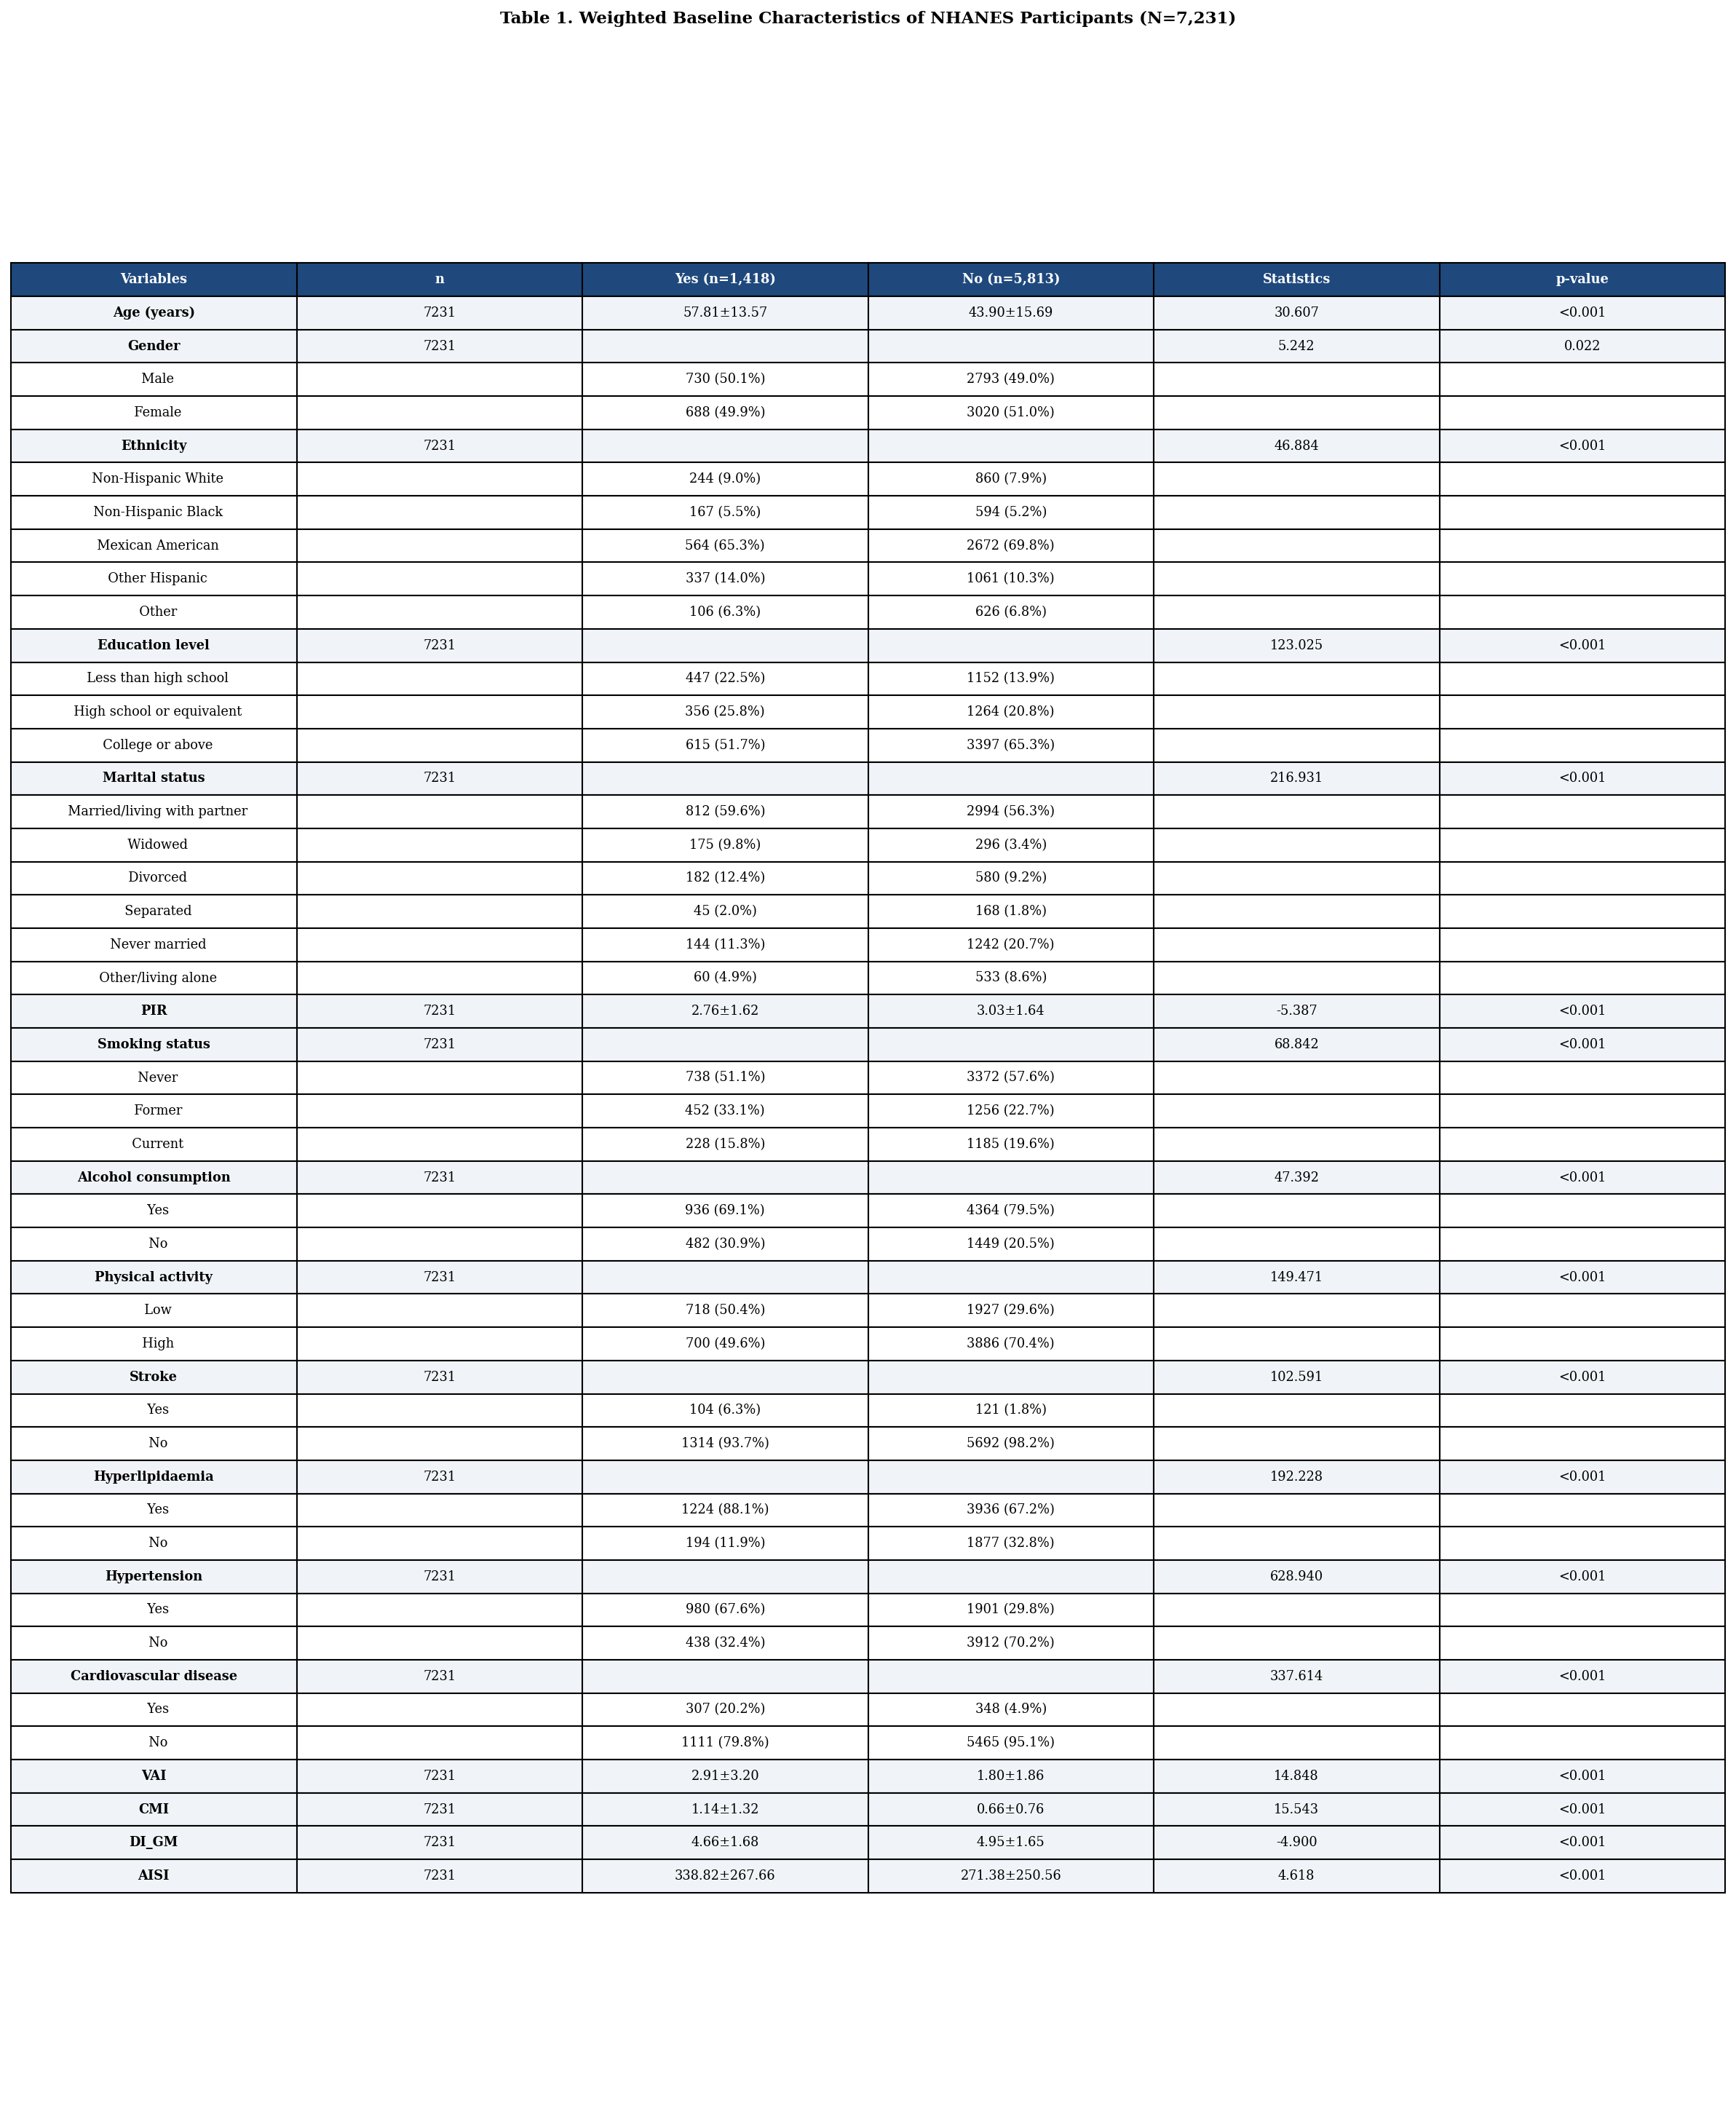

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Table1_Baseline.png
✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Table2_ML_Performance.csv


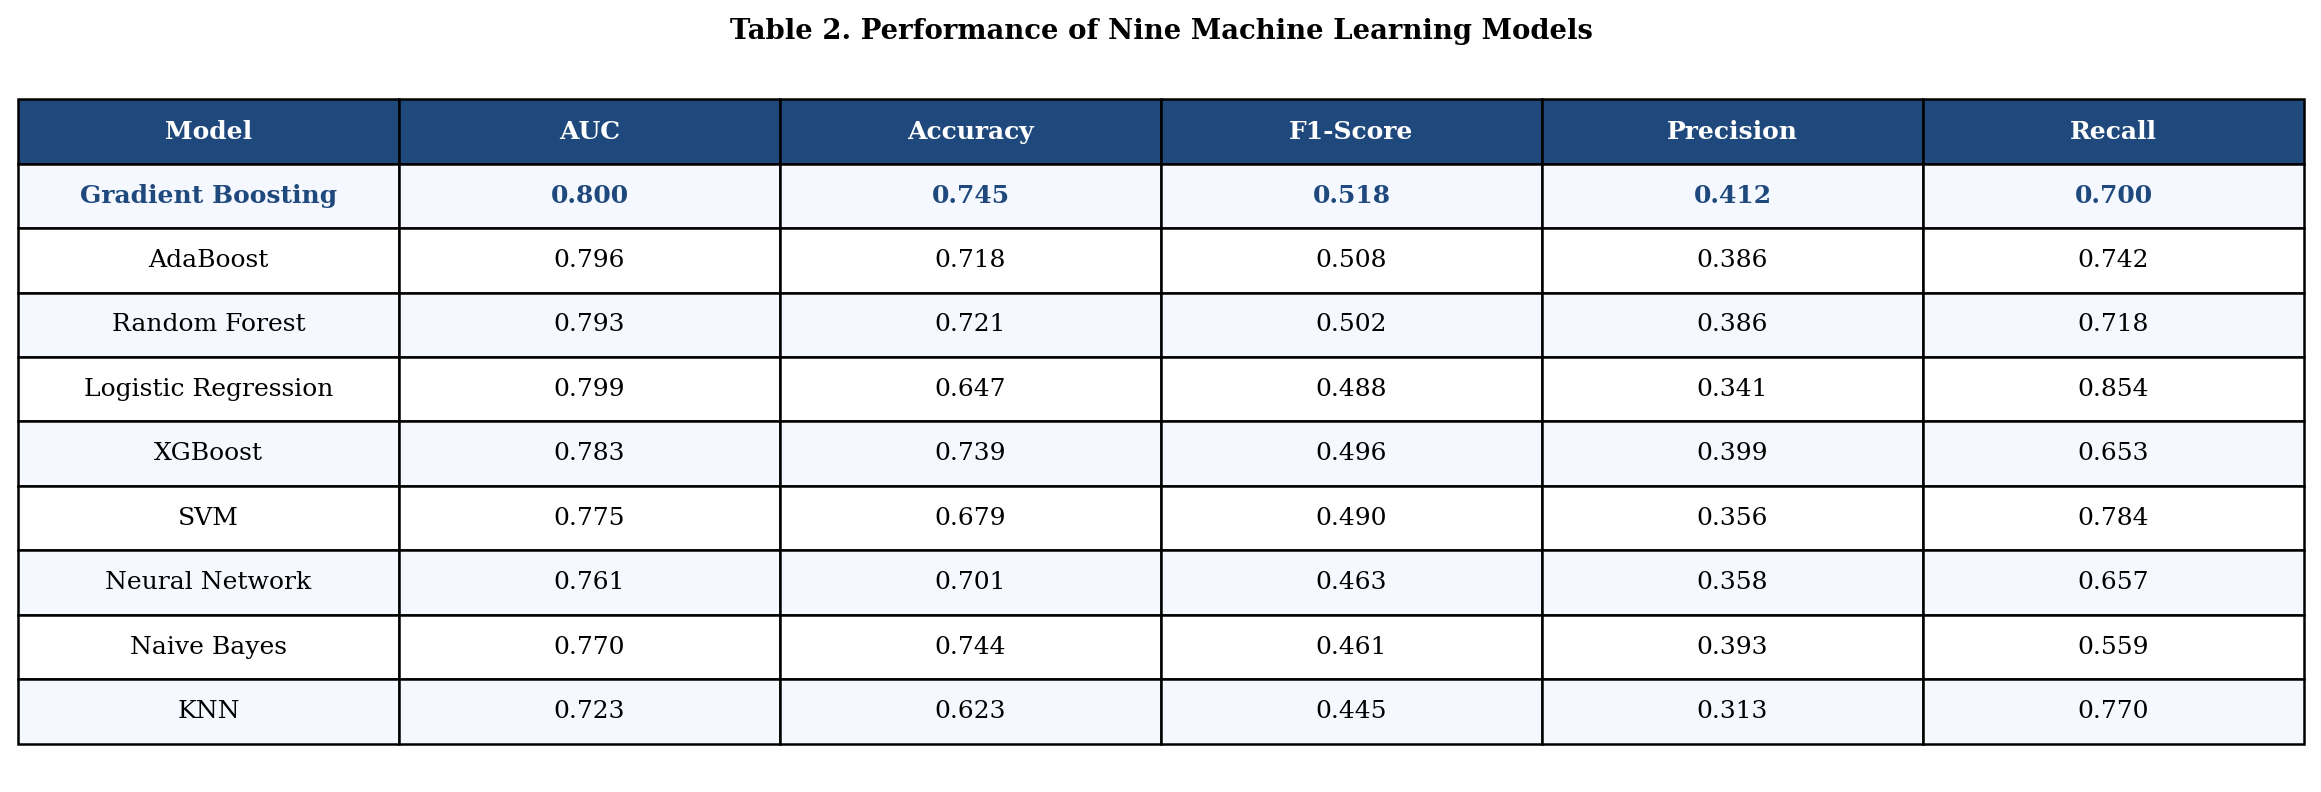

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Table2_ML_Performance.png


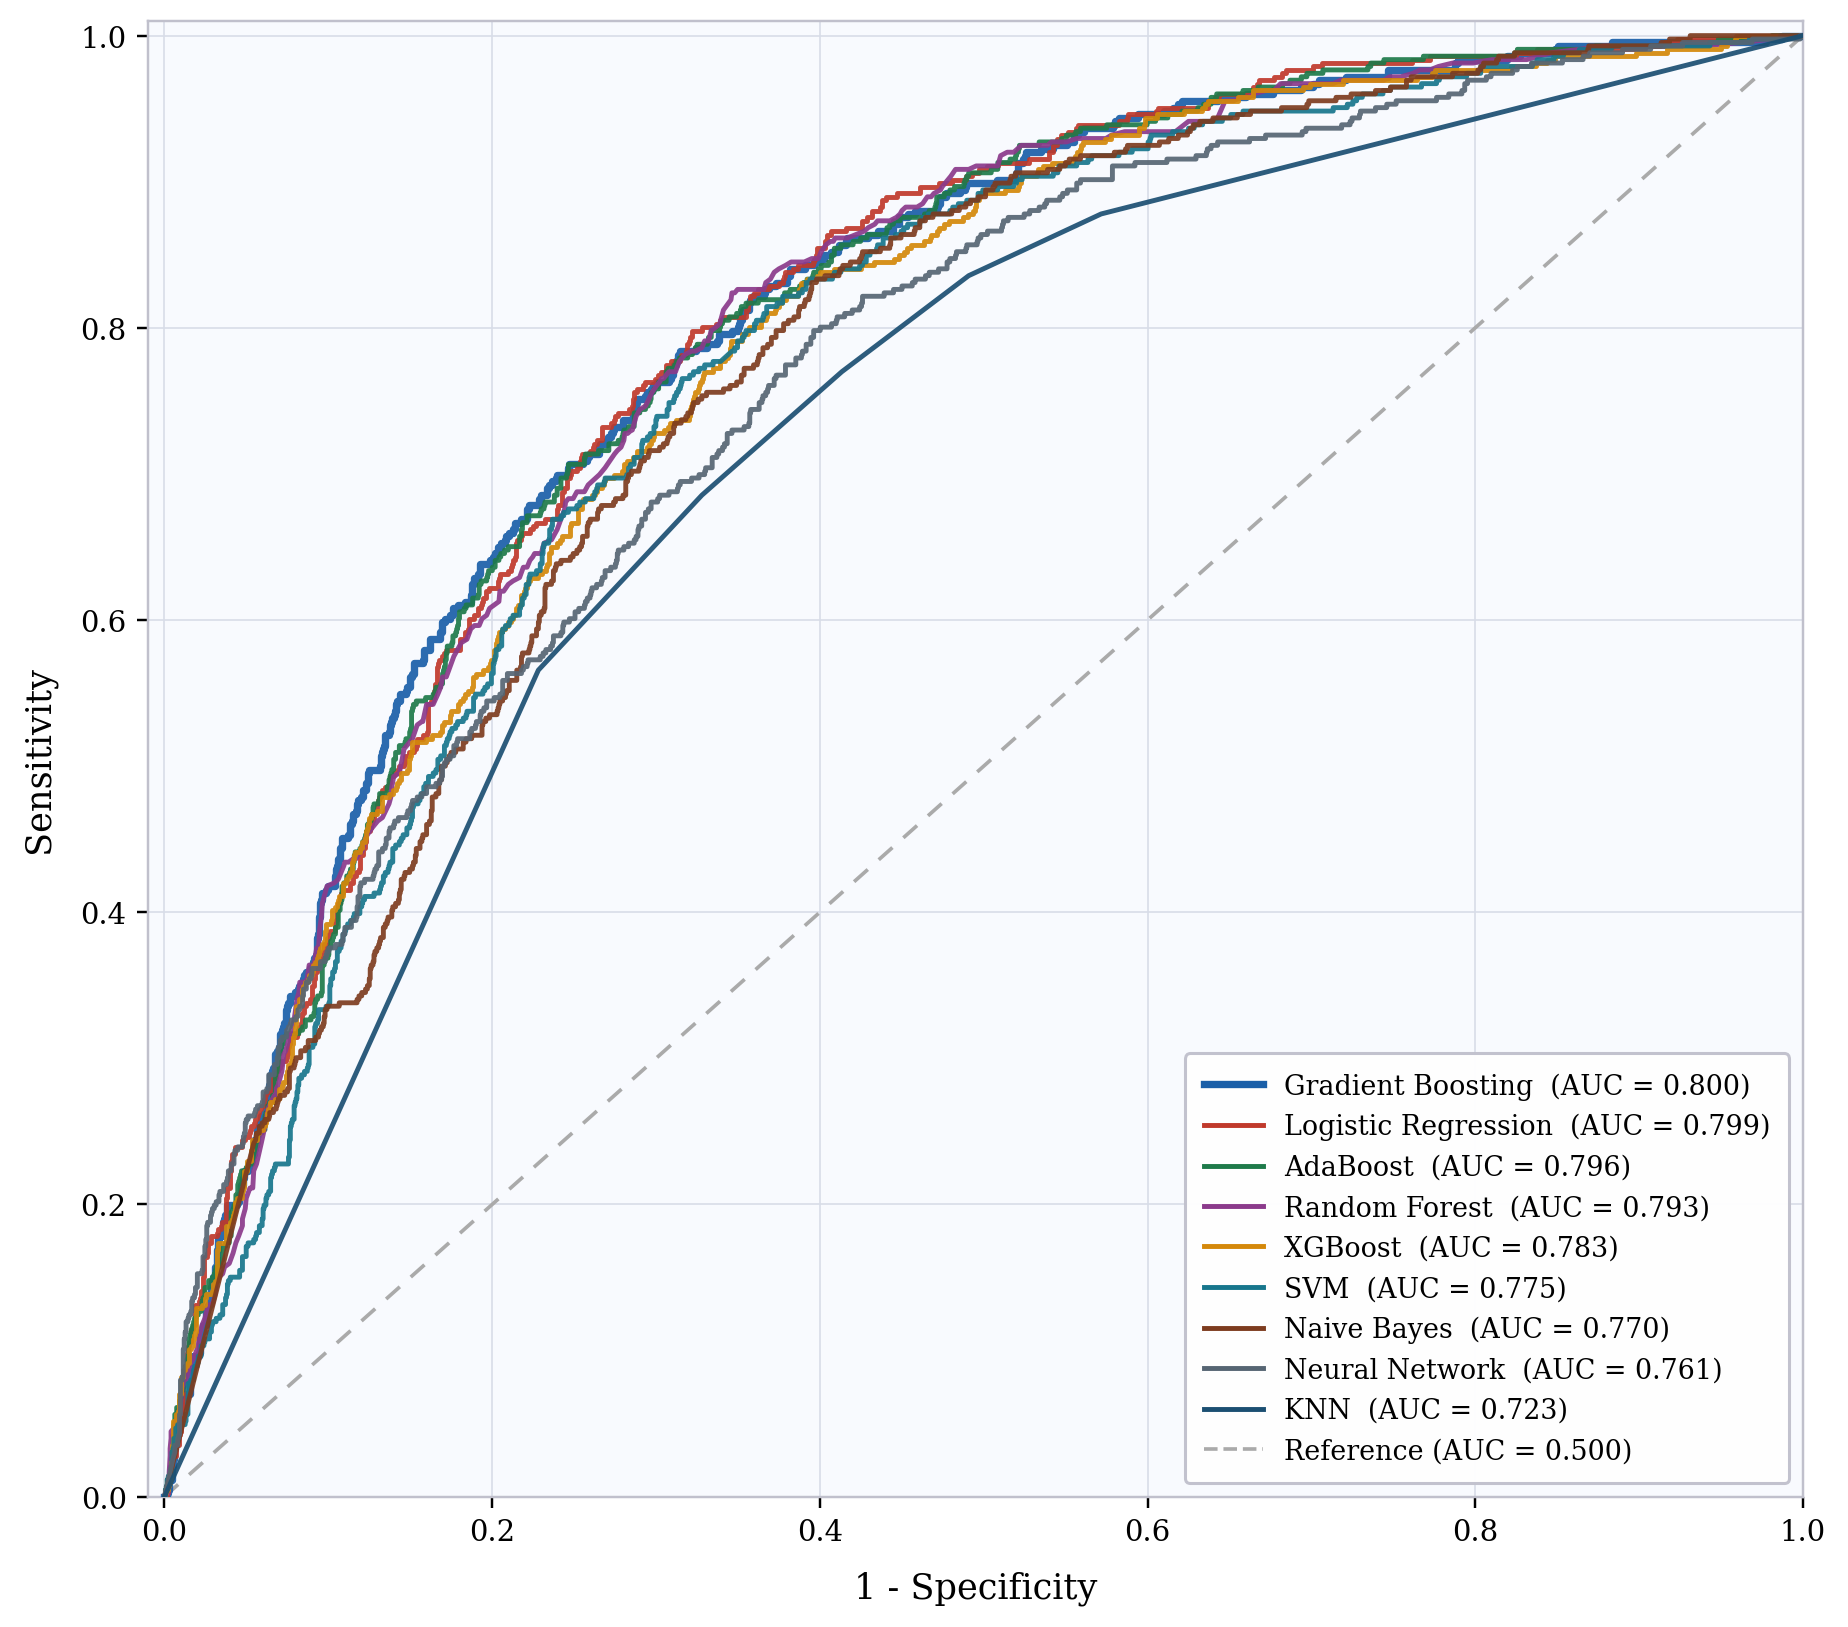

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Figure1_ROC.png
Computing SHAP values...
Top SHAP features:
  Age: 1.2917
  CMI: 0.7772
  DI_GM: 0.6031
  Hypertension: 0.5955
  Ethnicity: 0.4622
  VAI: 0.3608


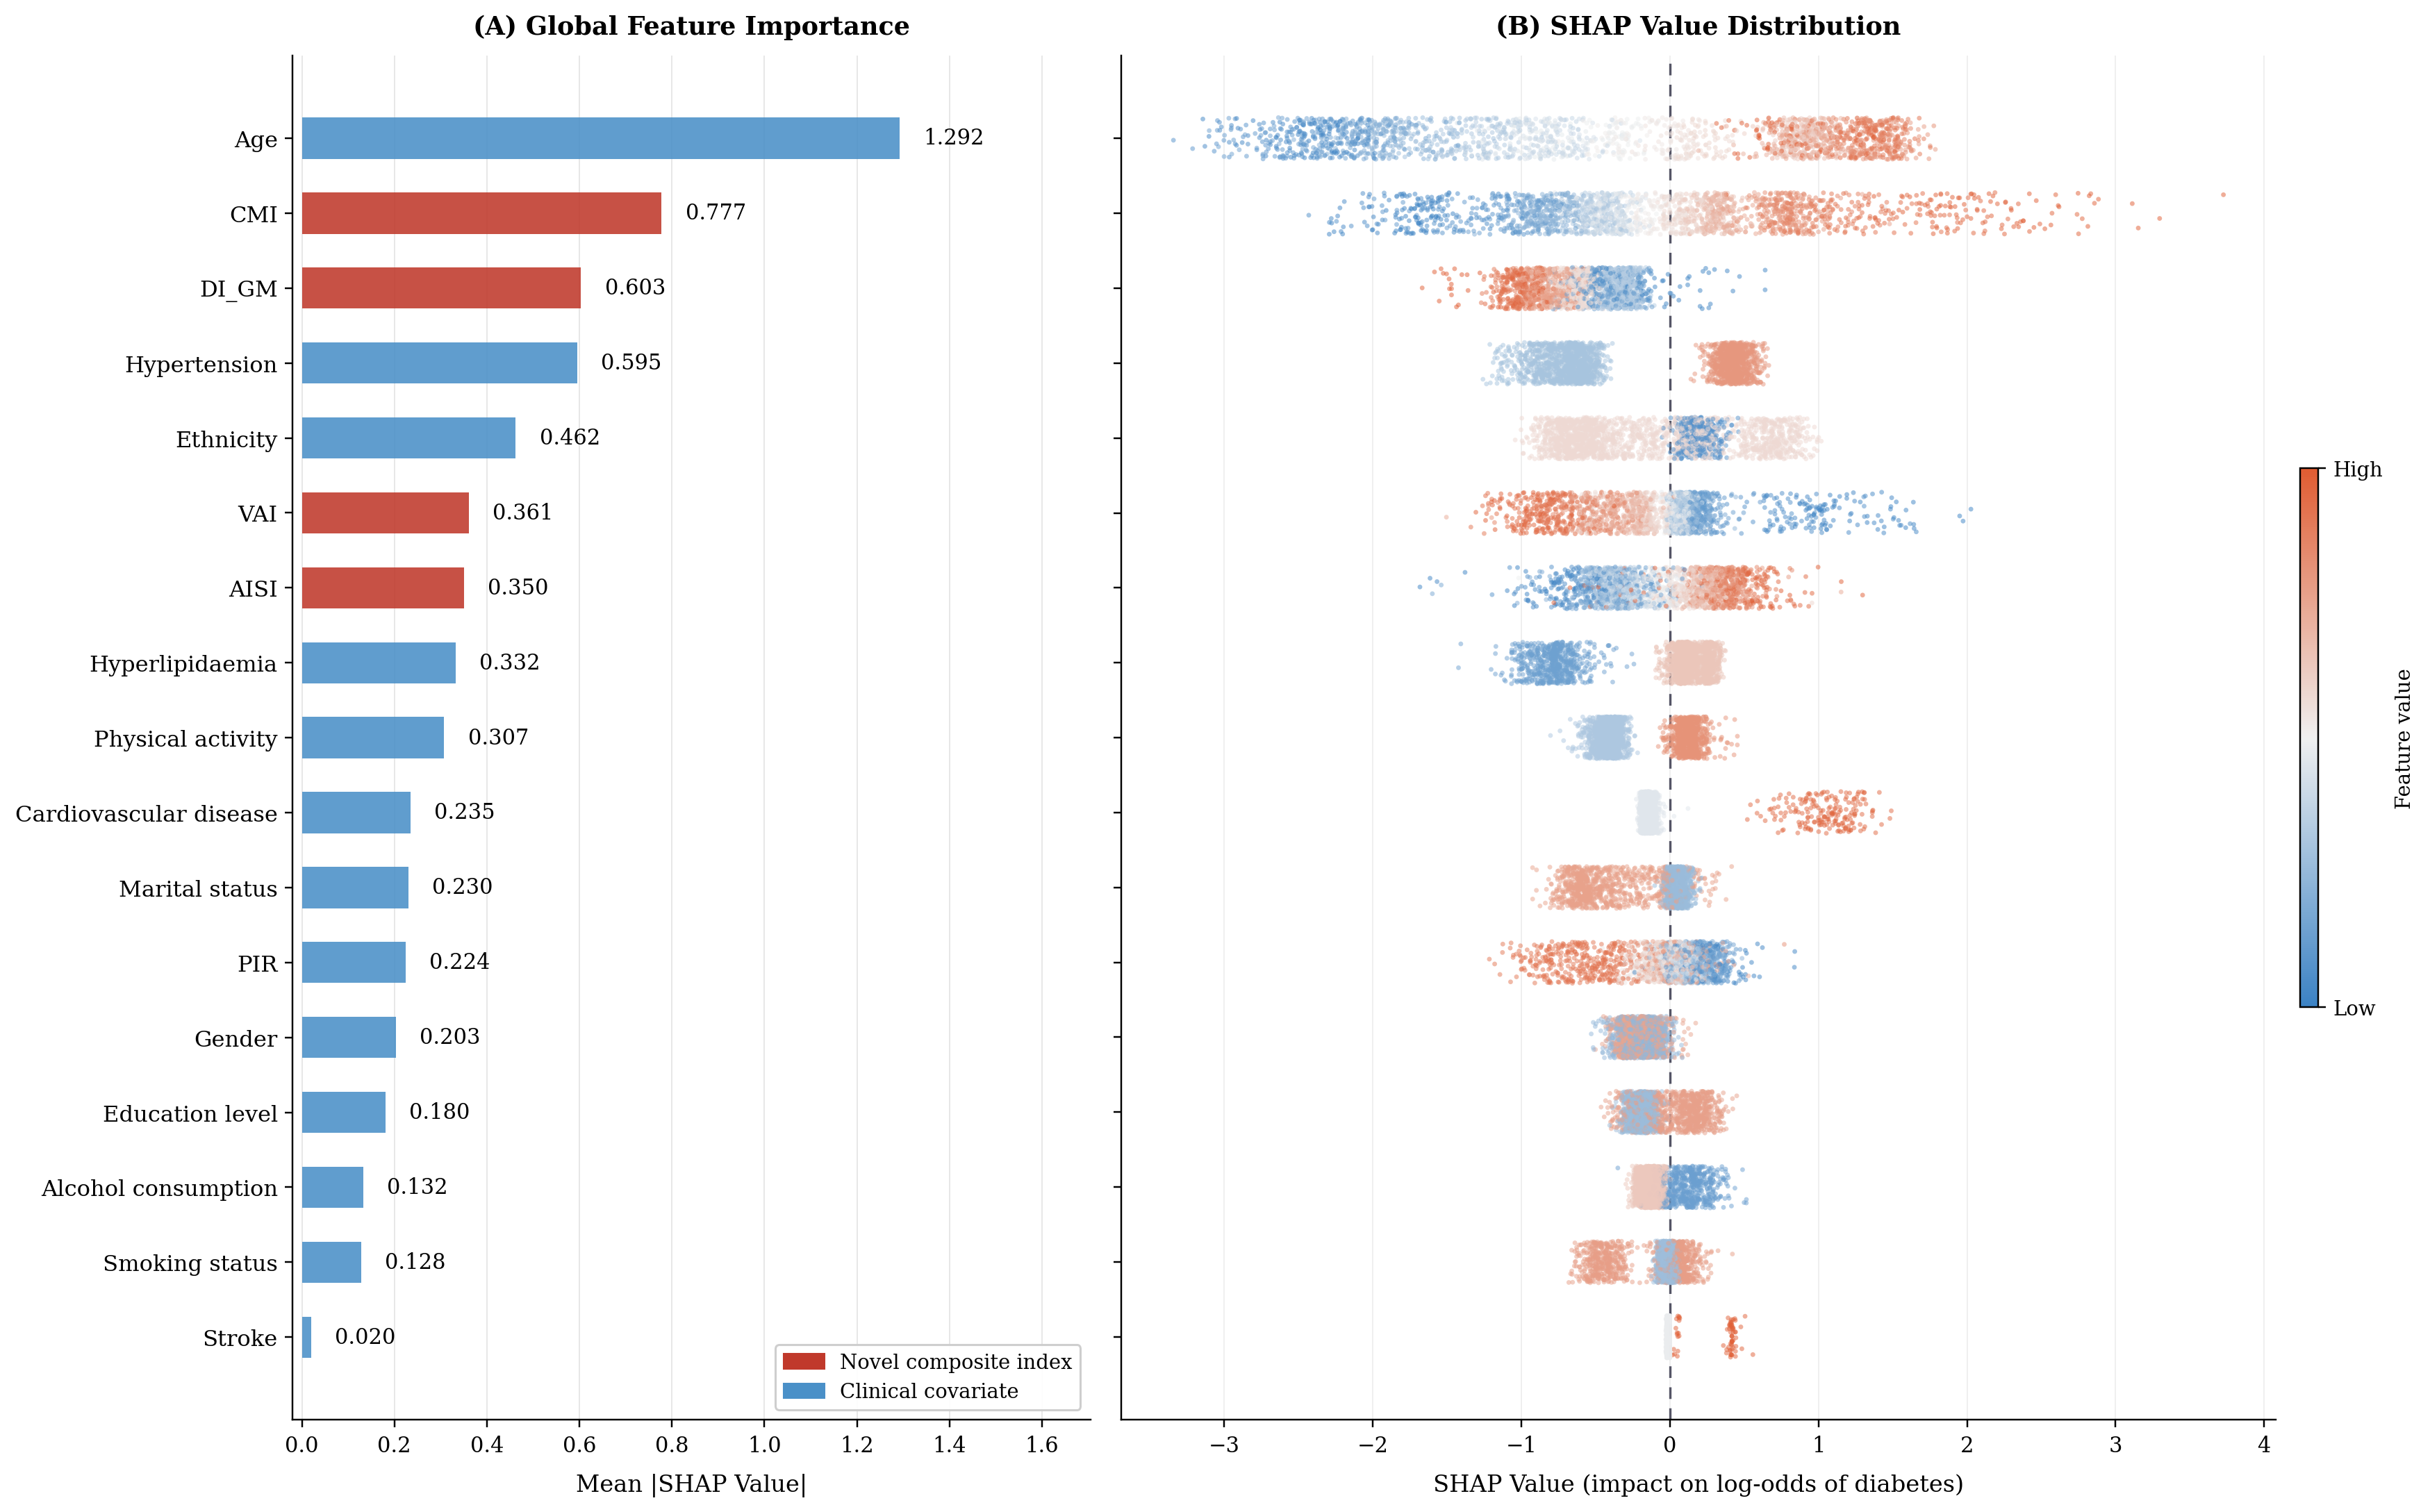

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Figure2_SHAP_Combined.png
Computing SHAP interaction values (n=500)...


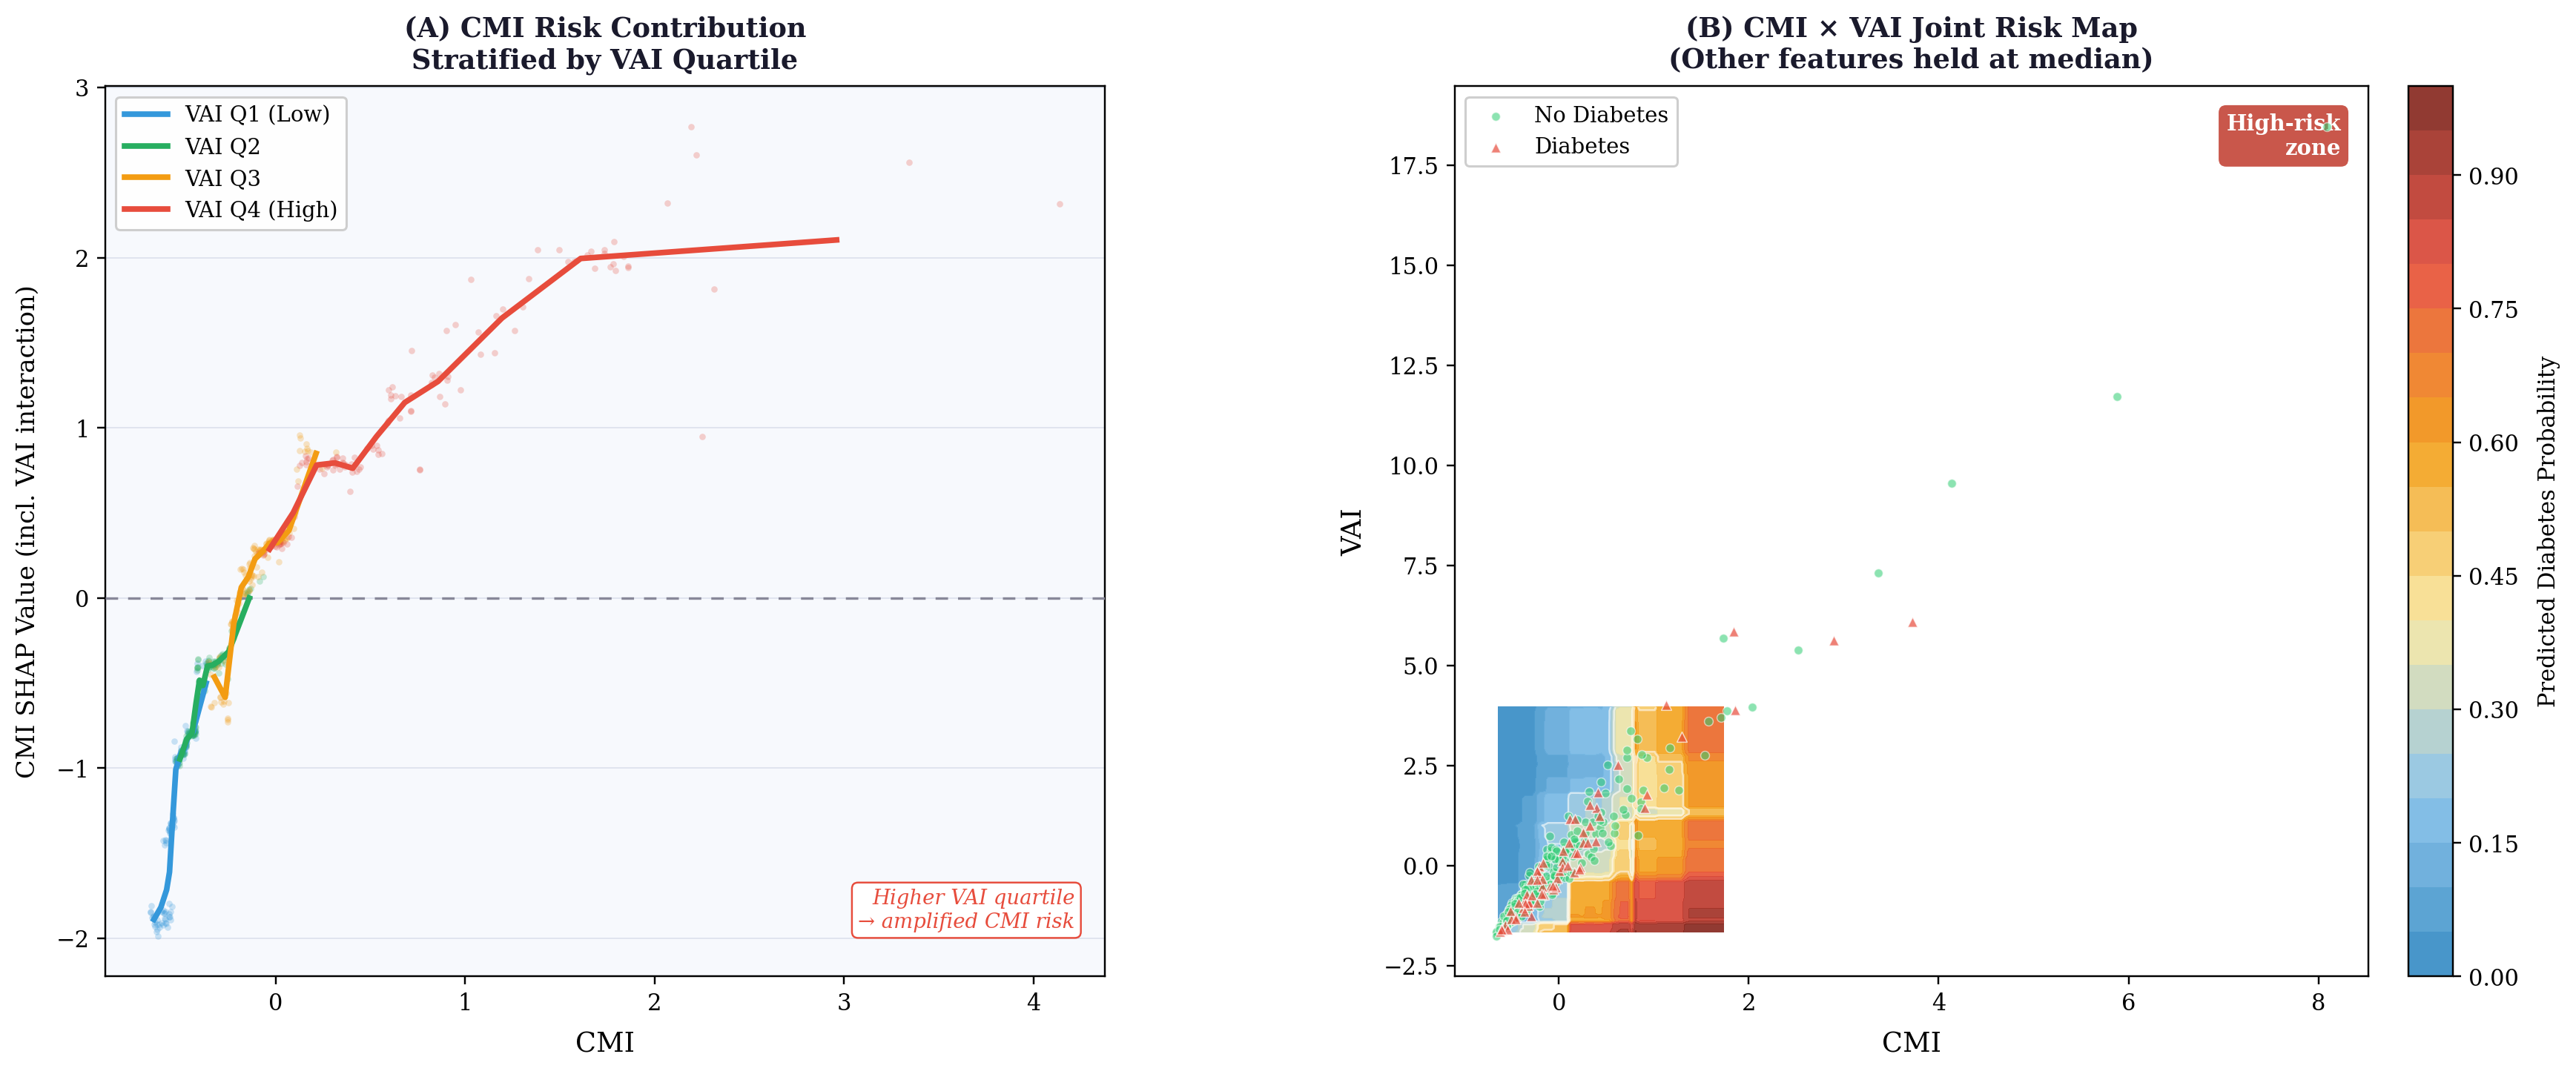

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Figure3_SHAP_CMI_VAI.png
  CMI: P-nonlinear <0.001
  VAI: P-nonlinear <0.001
  DI_GM: P-nonlinear = 0.160
  AISI: P-nonlinear <0.001


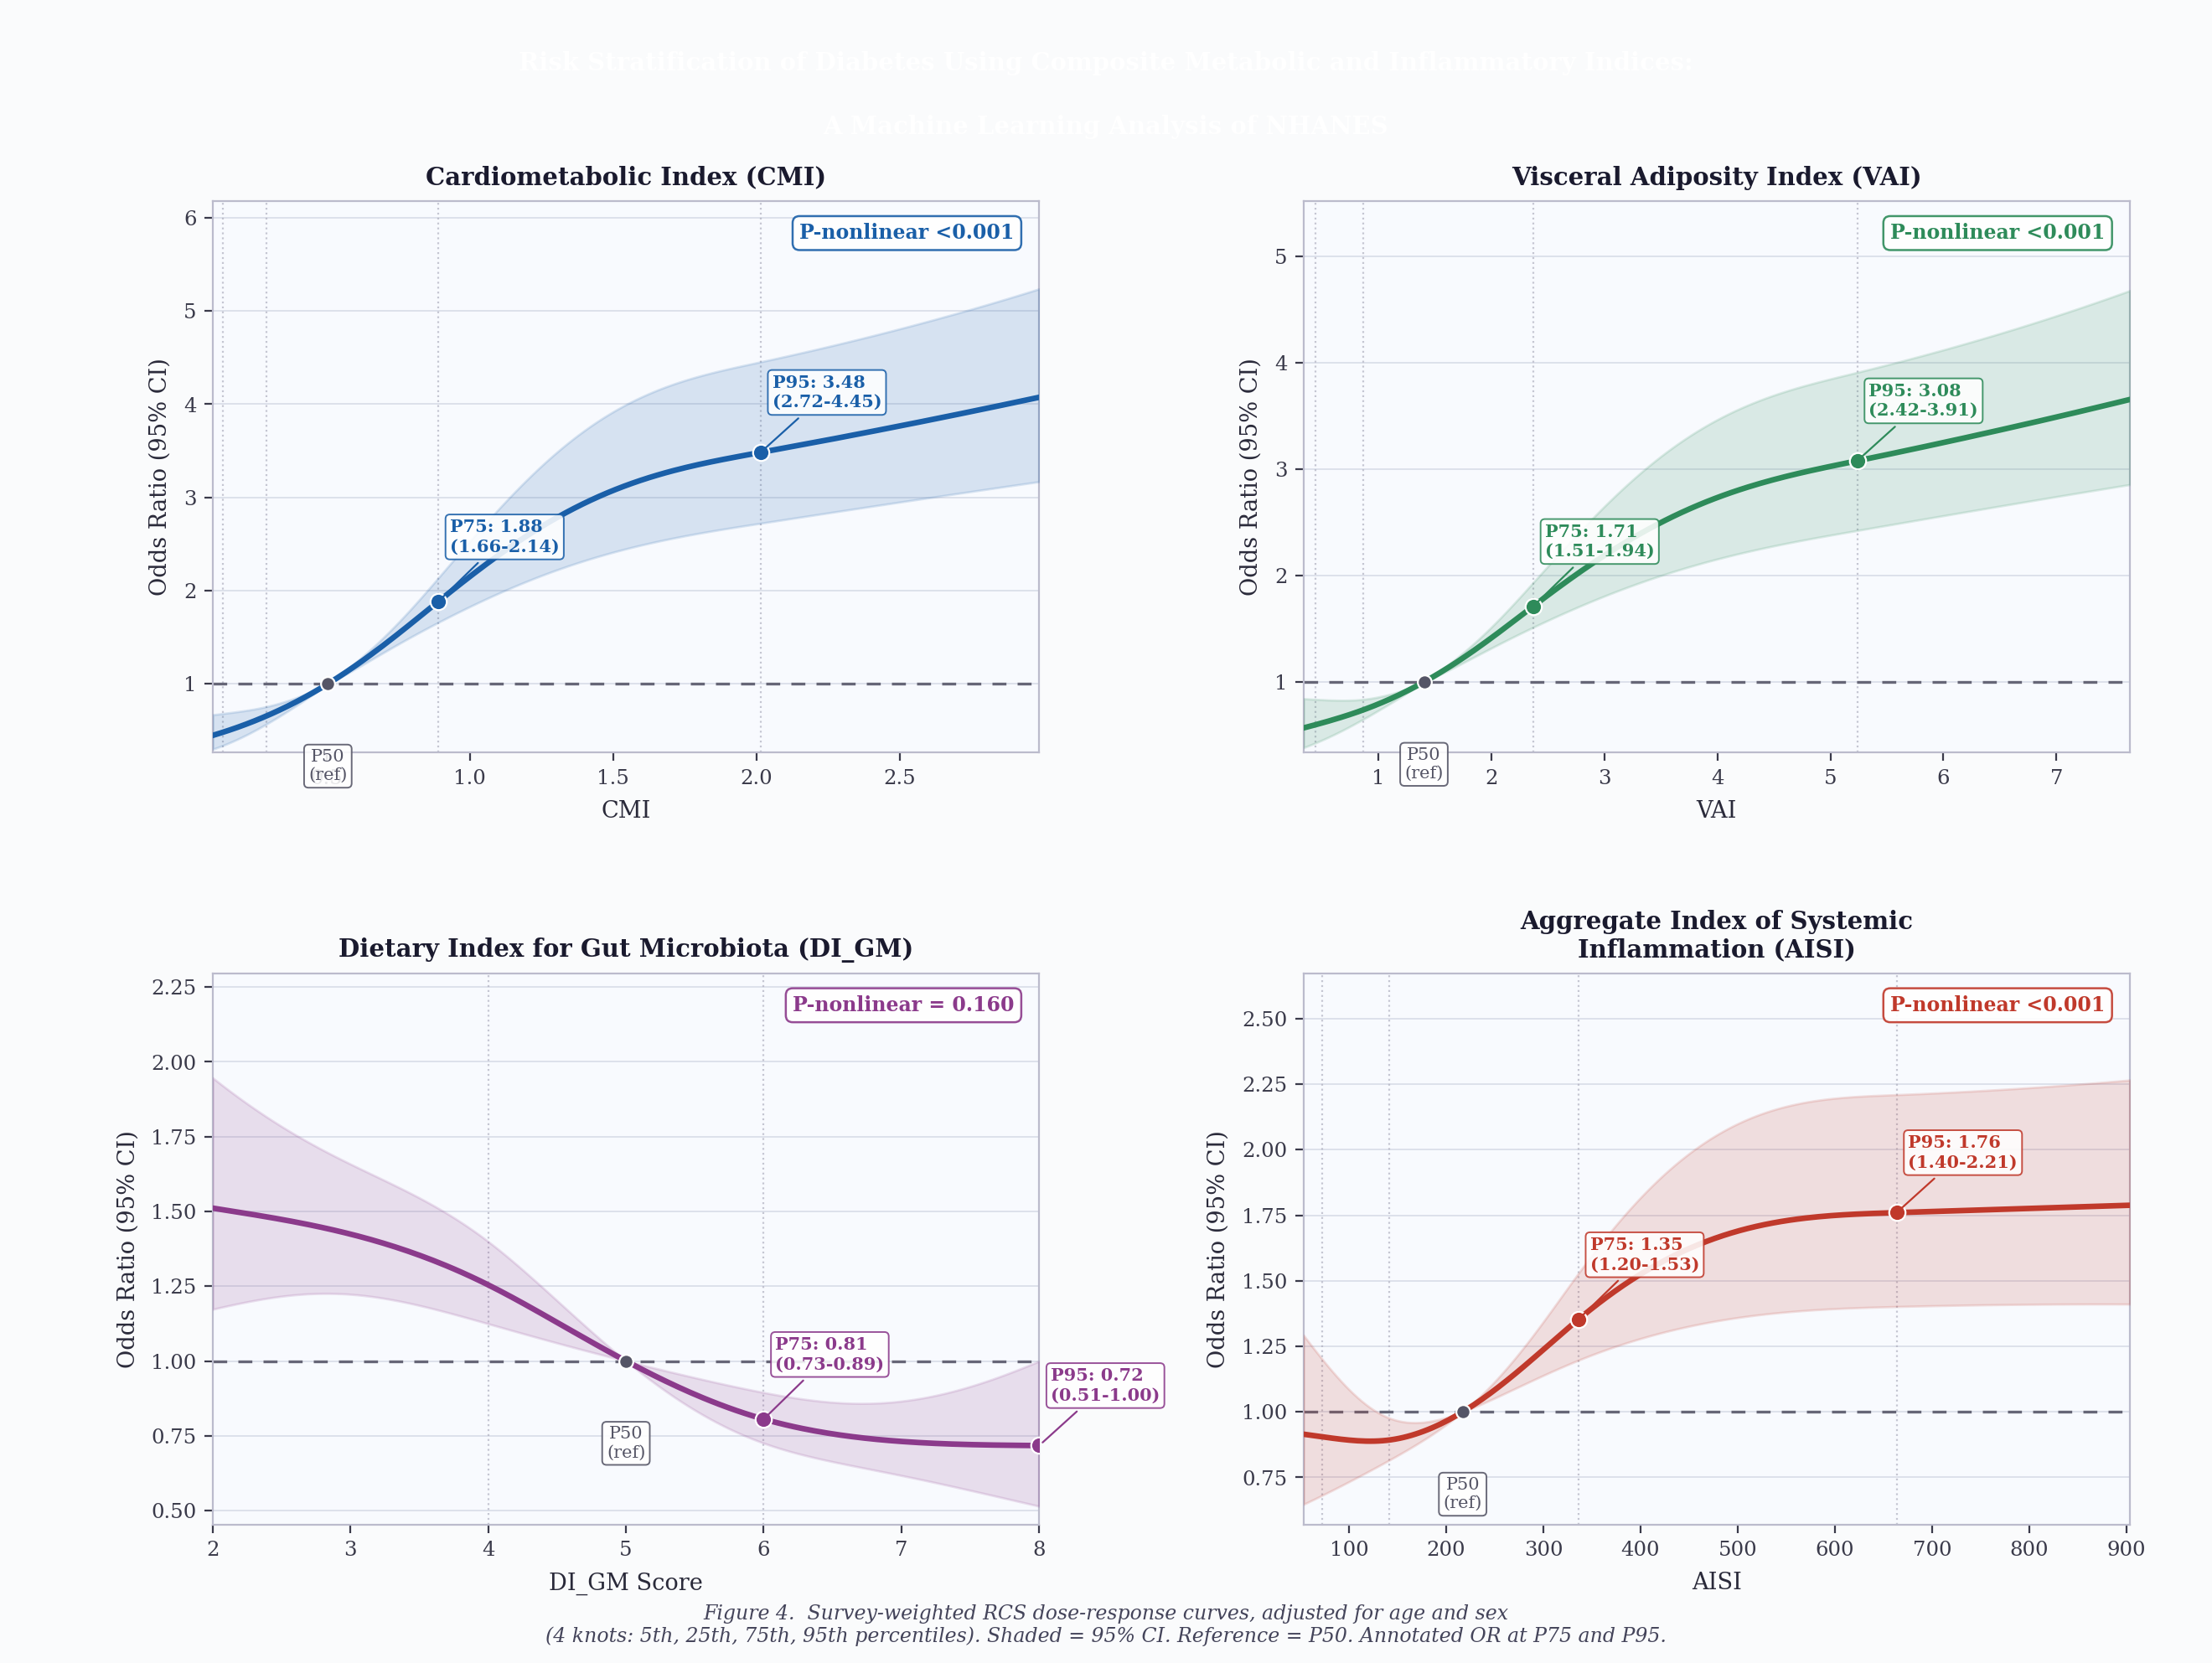

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Figure4_RCS.png
✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Table3_Regression.csv


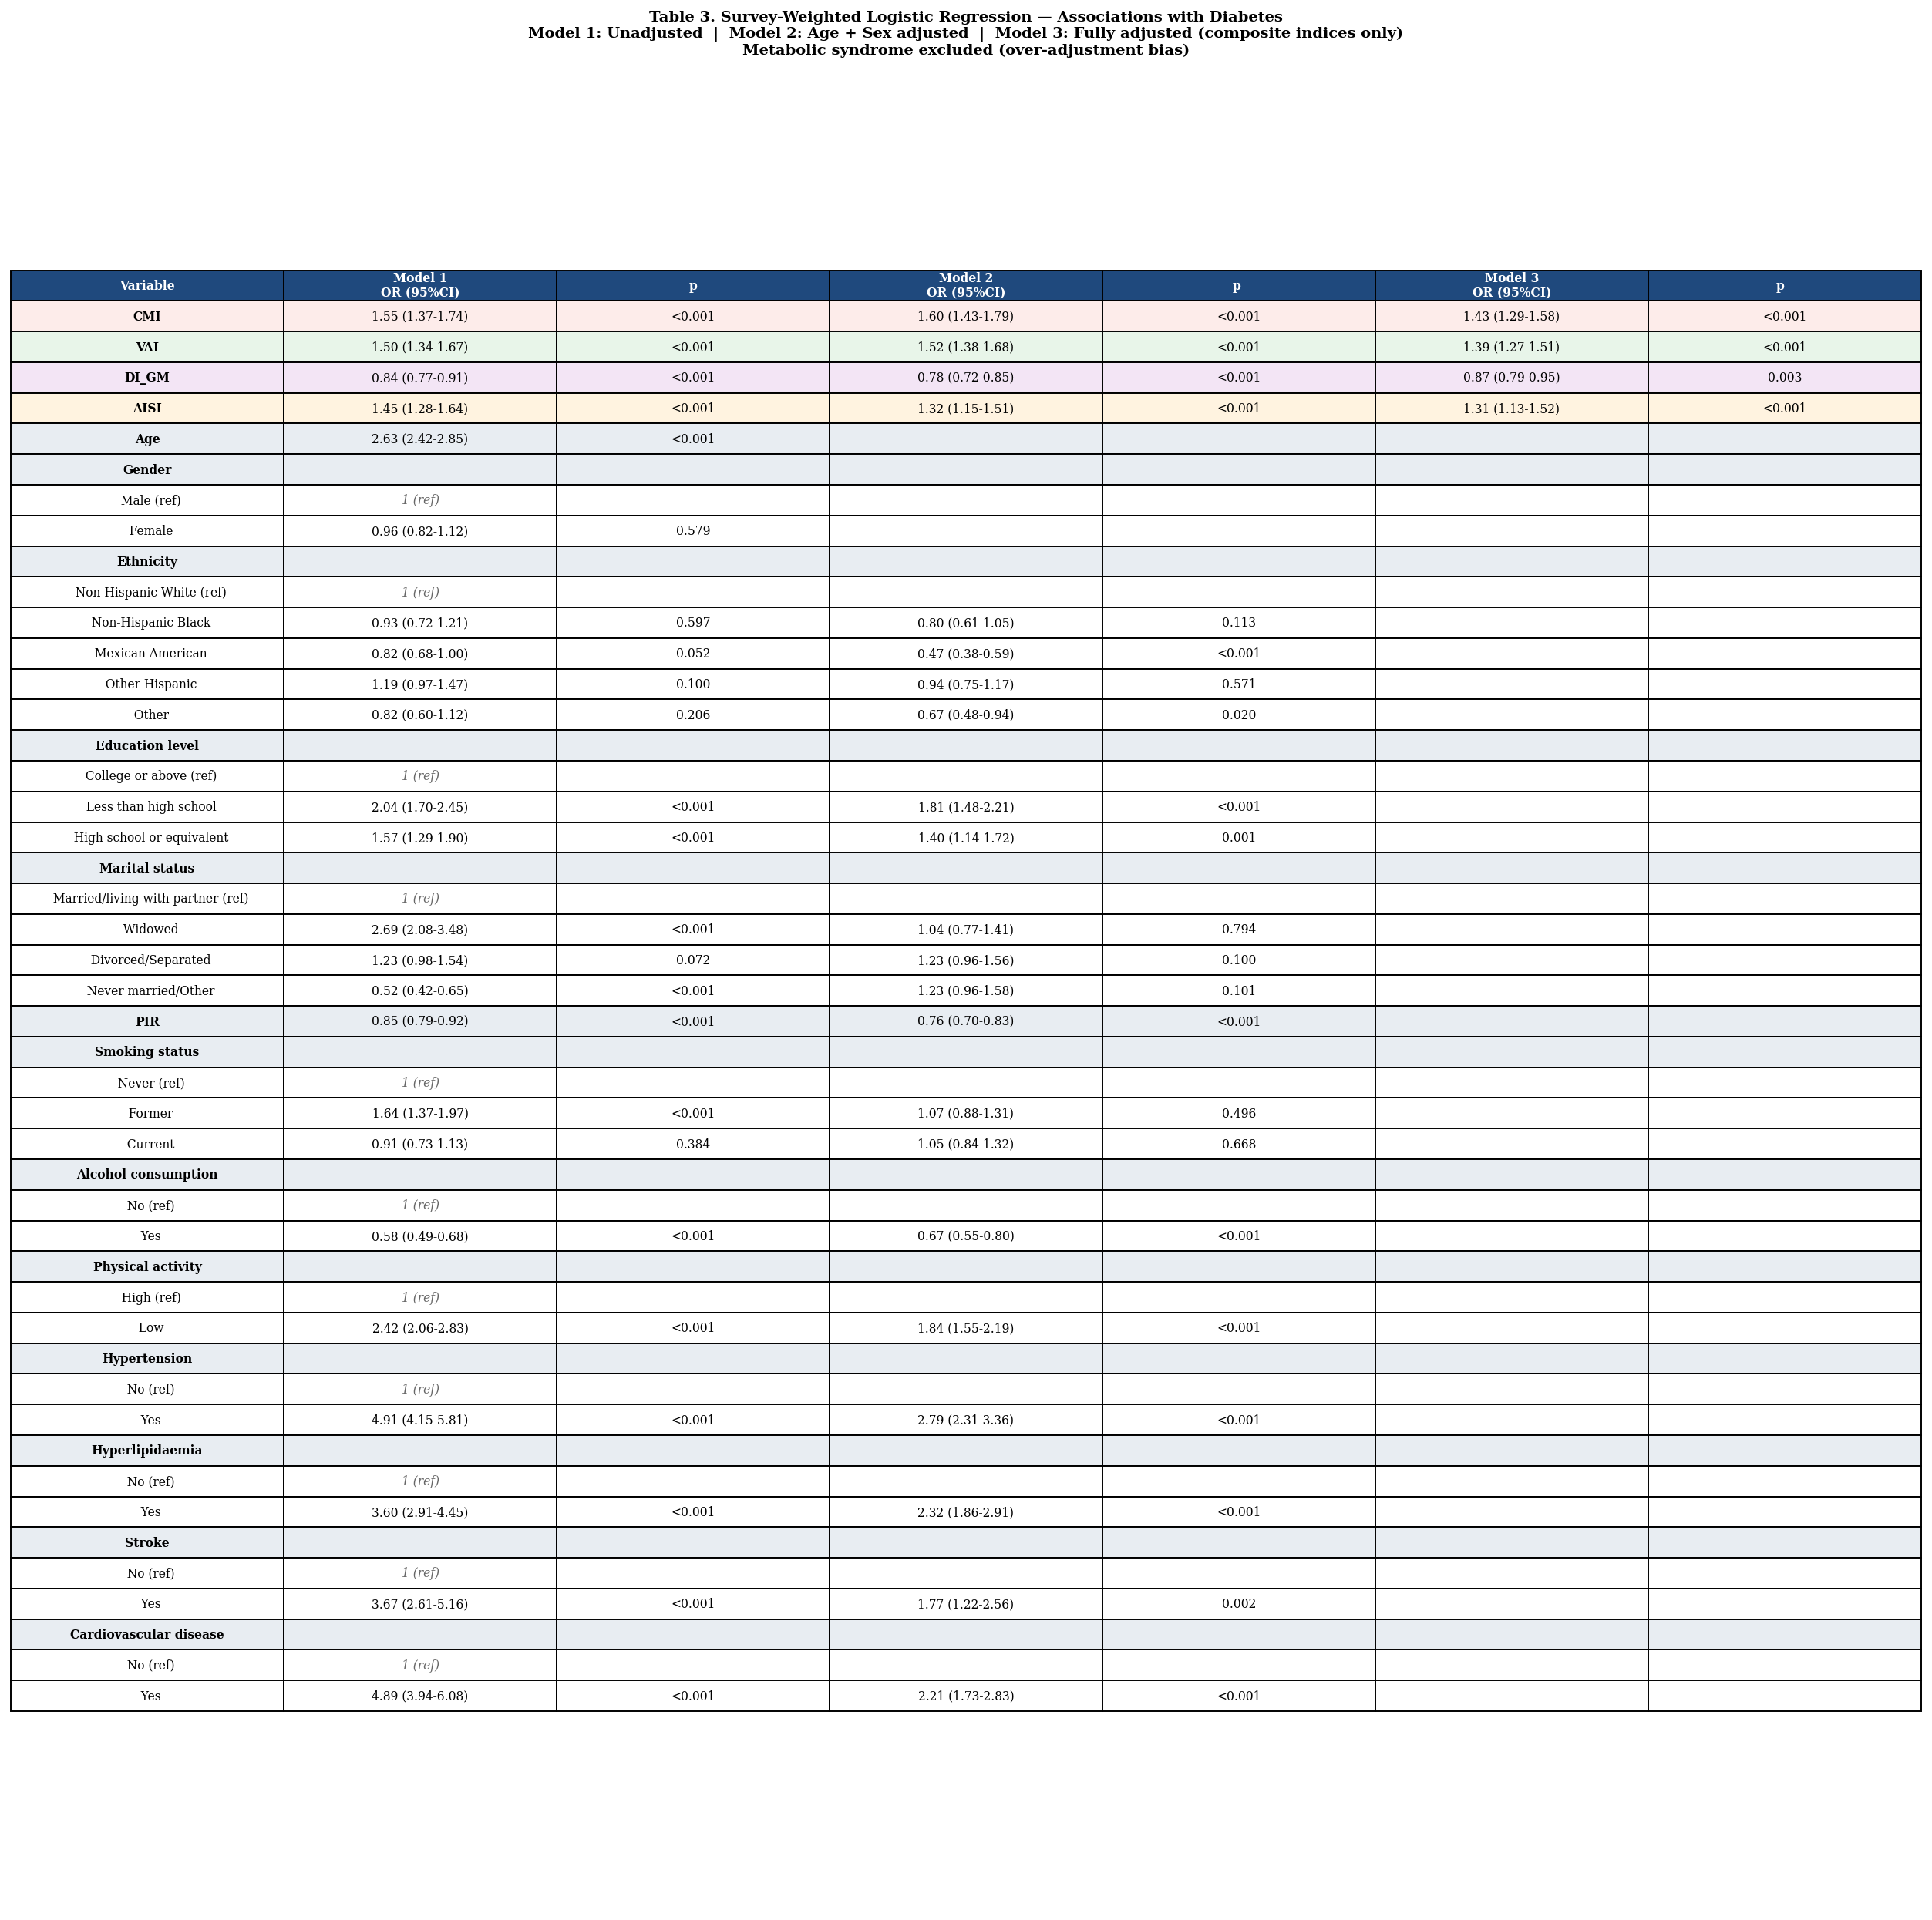

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Table3_Regression.png

SA-1 (n=6,744, DM=1,233)
  CMI: OR=1.41 (1.28-1.56), P=<0.001
  VAI: OR=1.37 (1.26-1.49), P=<0.001
  DI_GM: OR=0.86 (0.77-0.95), P=0.003
  AISI: OR=1.32 (1.12-1.56), P=0.001

SA-2 (n=6,879, DM=1,329)
  CMI: OR=1.82 (1.58-2.10), P=<0.001
  VAI: OR=1.66 (1.46-1.90), P=<0.001
  DI_GM: OR=0.88 (0.79-0.97), P=0.010
  AISI: OR=1.58 (1.34-1.86), P=<0.001

SA-3 Resampling
  SMOTEENN: AUC=0.7948
  SMOTE only: AUC=0.7926
  No resampling: AUC=0.7912
✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Table4_SensitivityAnalyses.csv


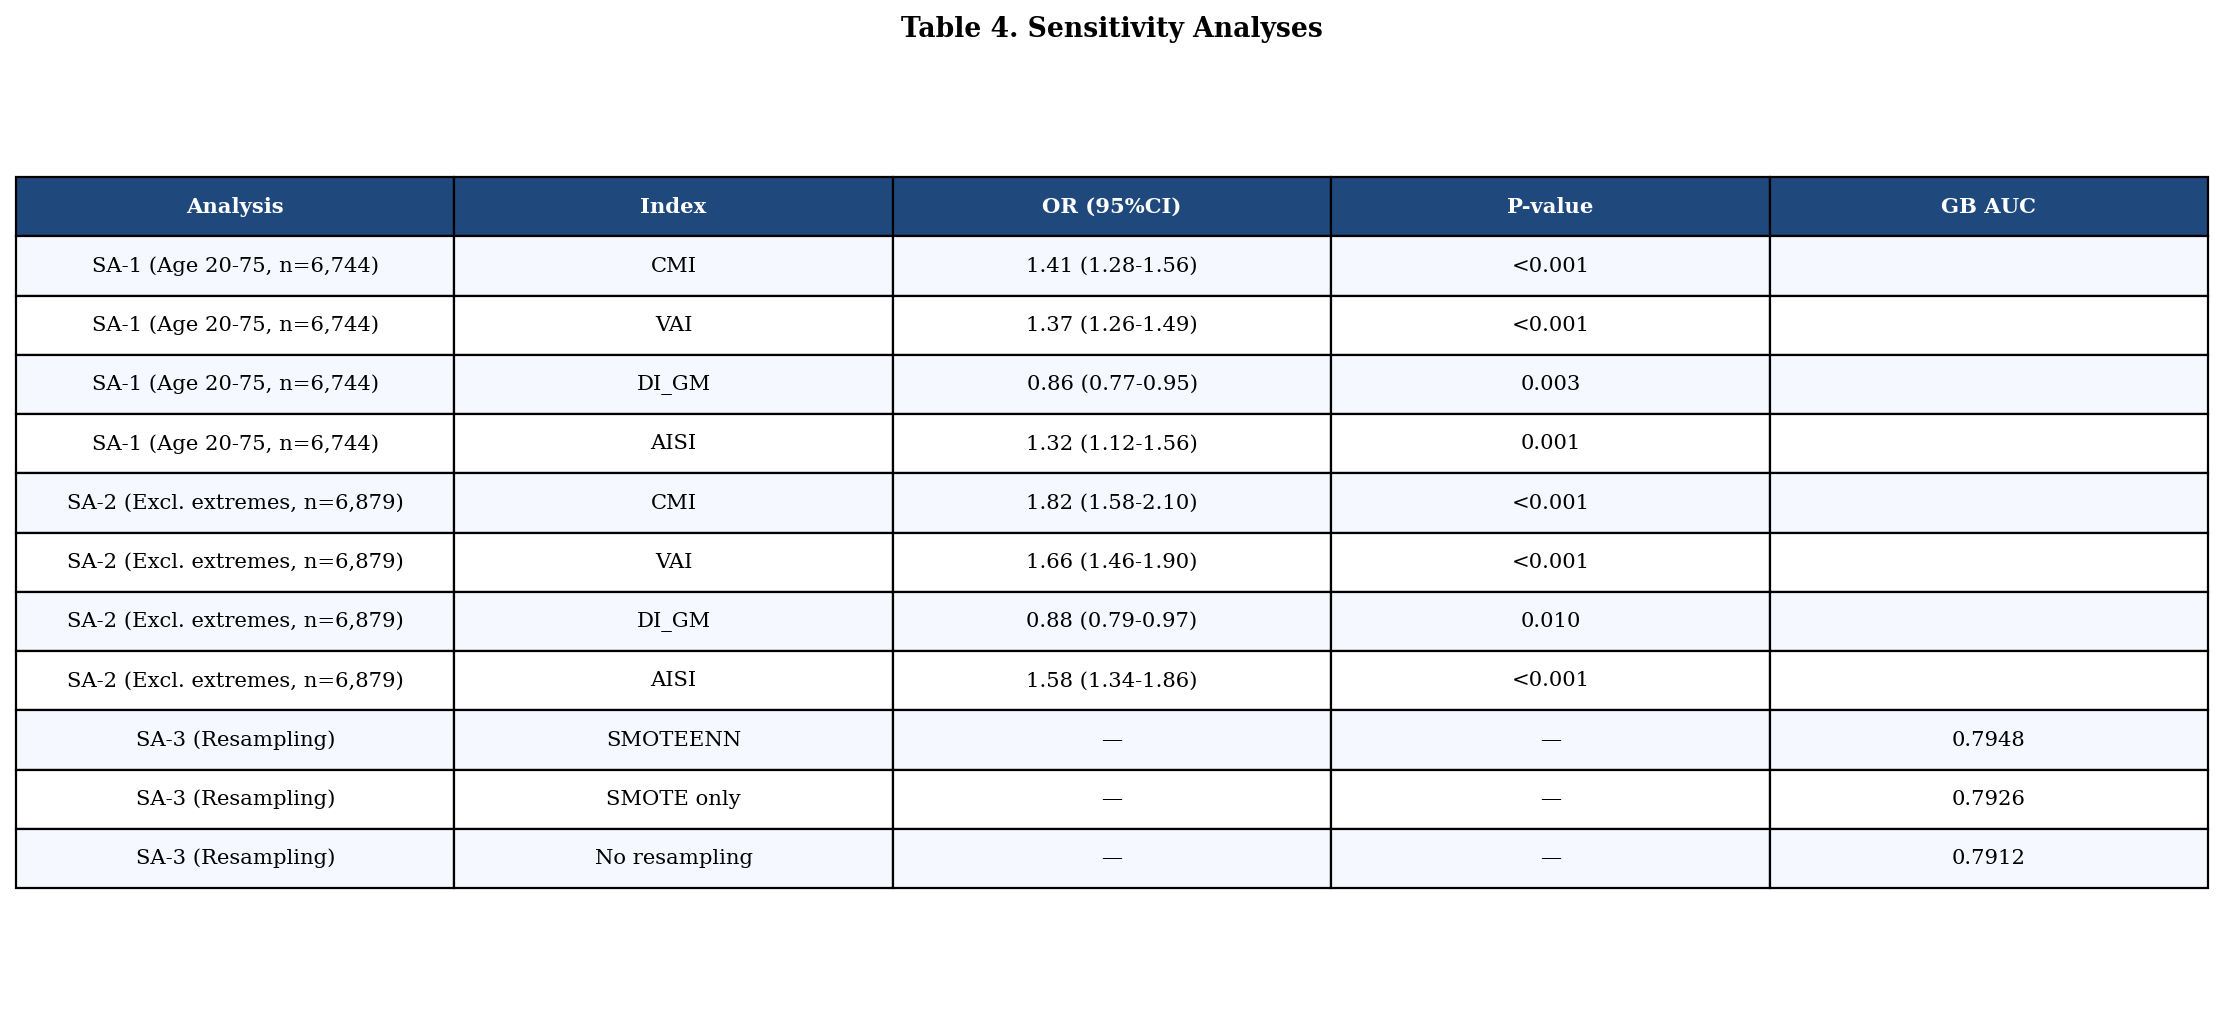

✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/Table4_SensitivityAnalyses.png
✓ Saved → /content/drive/MyDrive/The  second manuscript-zhaishuna/output/All_Results_Summary.json

✓  ALL OUTPUTS GENERATED
📂 /content/drive/MyDrive/The  second manuscript-zhaishuna/output

File                                                   Size
------------------------------------------------------------
  All_Results_Summary.json                             6 KB
  Figure1_ROC.png                                    308 KB
  Figure2_SHAP_Combined.png                          920 KB
  Figure3_SHAP_CMI_VAI.png                           286 KB
  Figure4_RCS.png                                    509 KB
  Table1_Baseline.csv                                  2 KB
  Table1_Baseline.png                                397 KB
  Table2_ML_Performance.csv                            0 KB
  Table2_ML_Performance.png                          122 KB
  Table3_Regression.csv                      

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  NHANES Diabetes ML Analysis — Complete Pipeline for Google Colab           ║
# ║  Metabolic syndrome EXCLUDED (over-adjustment bias: shares TG/HDL/WC        ║
# ║  components with CMI and VAI — Schisterman 2009; VanderWeele 2019)          ║
# ║  Run each cell in order. All outputs saved to Google Drive /output/          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════════════════════
# CELL 1: Mount Google Drive & Install Packages
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
for p in ['imbalanced-learn','shap','statsmodels','openpyxl']:
    subprocess.run([sys.executable,'-m','pip','install',p,'-q'])

# ══════════════════════════════════════════════════════════════════════════════
# CELL 2: Setup Paths
# ══════════════════════════════════════════════════════════════════════════════
import os, glob

print("=== MyDrive folders ===")
for item in sorted(os.listdir('/content/drive/MyDrive')):
    print(f"  {item}")

candidates = [f for f in os.listdir('/content/drive/MyDrive')
              if 'manuscript' in f.lower() or 'second' in f.lower()]
if candidates:
    BASE = os.path.join('/content/drive/MyDrive', candidates[0])
    print(f"\n✓ Auto-detected: {BASE}")
else:
    MANUAL_BASE = ''   # ← Fill in if auto-detect fails
    if MANUAL_BASE:
        BASE = os.path.join('/content/drive/MyDrive', MANUAL_BASE)
    else:
        raise ValueError("Fill in MANUAL_BASE with your Google Drive folder name")

INPUT  = os.path.join(BASE, 'input')
OUTPUT = os.path.join(BASE, 'output')
os.makedirs(OUTPUT, exist_ok=True)

excel_files = glob.glob(os.path.join(INPUT, '*.xlsx'))
EXCEL_PATH  = excel_files[0] if excel_files else None
print(f"\n📂 Input : {INPUT}")
print(f"📂 Output: {OUTPUT}")
print(f"📊 Excel : {EXCEL_PATH}")
print(f"\n=== Input files ===")
for f in os.listdir(INPUT): print(f"  {f}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: Imports & Data Preparation
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, warnings, json
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams.update({'font.family':'DejaVu Serif'})
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import rankdata, binned_statistic, chi2, ttest_ind, chi2_contingency
import statsmodels.api as sm
import shap
from sklearn.ensemble import (GradientBoostingClassifier, RandomForestClassifier,
                               AdaBoostClassifier)
from sklearn.linear_model  import LogisticRegression
from sklearn.svm            import SVC
from sklearn.naive_bayes    import GaussianNB
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing  import StandardScaler
from xgboost                import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              f1_score, precision_score, recall_score)
from imblearn.combine       import SMOTEENN
from imblearn.over_sampling import SMOTE

df = pd.read_excel(EXCEL_PATH)
df['w']           = df['cycle_weight'] / df['cycle_weight'].mean()
df['Female']      = (df['Gender']==2).astype(float)
df['Age_std']     = (df['Age'] - df['Age'].mean()) / df['Age'].std()
df['PIR_std']     = (df['PIR'] - df['PIR'].mean()) / df['PIR'].std()
for col,cs in [('CMI','CMI_std'),('VAI','VAI_std'),
               ('DI_GM','DIGM_std'),('AISI','AISI_std')]:
    df[cs] = df[col] / df[col].std()
for v,r in [(2,'NHBlack'),(3,'MexAm'),(4,'OtherHisp'),(5,'Other')]:
    df[f'Race_{r}'] = (df['Race']==v).astype(float)
for v,r in [(1,'LtHS'),(2,'HS')]:
    df[f'Edu_{r}'] = (df['Education']==v).astype(float)
df['Mar_Widowed']    = (df['Marital']==2).astype(float)
df['Mar_DivSep']     = df['Marital'].isin([3,4]).astype(float)
df['Mar_NeverOther'] = df['Marital'].isin([5,6]).astype(float)
df['Smoke_Former']   = (df['Smoking']==1).astype(float)
df['Smoke_Current']  = (df['Smoking']==2).astype(float)
df['PA_Low']         = (df['Physical_activity']==1).astype(float)

# 24 features — Metabolic syndrome EXCLUDED
FEATURES = ['CMI_std','VAI_std','DIGM_std','AISI_std','Age_std','Female',
            'Race_NHBlack','Race_MexAm','Race_OtherHisp','Race_Other',
            'Edu_LtHS','Edu_HS','Mar_Widowed','Mar_DivSep','Mar_NeverOther',
            'PIR_std','Smoke_Former','Smoke_Current','Alcohol','PA_Low',
            'Hypertension','Hyperlipidemia','Stroke','CVD']

FEAT_DISPLAY = ['CMI','VAI','DI_GM','AISI','Age','Gender',
                'Non-Hispanic Black','Mexican American','Other Hispanic','Other Race',
                'Education: <High school','Education: High school',
                'Marital: Widowed','Marital: Divorced/Separated','Marital: Never/Other',
                'PIR','Smoking: Former','Smoking: Current','Alcohol consumption','Physical activity',
                'Hypertension','Hyperlipidaemia','Stroke','Cardiovascular disease']

BASE = ['Age_std','Female','Race_NHBlack','Race_MexAm','Race_OtherHisp','Race_Other',
        'Edu_LtHS','Edu_HS','Mar_Widowed','Mar_DivSep','Mar_NeverOther','PIR_std',
        'Smoke_Former','Smoke_Current','Alcohol','PA_Low',
        'Hypertension','Hyperlipidemia','Stroke','CVD']

y_all = df['Diabetes'].values.astype(float)
X = df[FEATURES].values
y = df['Diabetes'].values.astype(int)
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

# Standardise BEFORE SMOTEENN — SMOTEENN uses KNN distance metrics
sc = StandardScaler().fit(X_tr)        # fit on raw training set only
X_tr_s = sc.transform(X_tr)           # standardised training set
X_te_s = sc.transform(X_te)           # standardised test set (same scaler)
X_res, y_res = SMOTEENN(random_state=42).fit_resample(X_tr_s, y_tr)  # SMOTEENN on scaled data

dm  = df[df['Diabetes']==1].copy()
ndm = df[df['Diabetes']==0].copy()
N_DM=len(dm); N_NDM=len(ndm); N_TOT=len(df)

print(f"n={N_TOT:,}, DM={N_DM:,} ({y.mean()*100:.1f}%)")
print(f"Train={len(X_tr):,}, Test={len(X_te):,}, Resampled={len(X_res):,}")
print(f"Features: {len(FEATURES)} (Metabolic syndrome excluded)")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 4: Nine ML Models
# ══════════════════════════════════════════════════════════════════════════════
# Standardisation already applied in CELL 3 before SMOTEENN
# X_res and X_te_s are both standardised — use directly for all models

MODELS = [
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=300,random_state=42), False),
    ('AdaBoost',            AdaBoostClassifier(n_estimators=300,random_state=42),          False),
    ('Random Forest',       RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1),False),
    ('Logistic Regression', LogisticRegression(max_iter=1000,random_state=42),             True),
    ('XGBoost',             XGBClassifier(n_estimators=300,random_state=42,
                                          eval_metric='logloss',verbosity=0),             False),
    ('SVM',                 SVC(probability=True,random_state=42),                         True),
    ('Neural Network',      MLPClassifier(hidden_layer_sizes=(100,50),max_iter=500,
                                          random_state=42),                                True),
    ('Naive Bayes',         GaussianNB(),                                                  False),
    ('KNN',                 KNeighborsClassifier(n_neighbors=5,n_jobs=-1),                 True),
]
results = {}
print(f"\n{'Model':<25}{'AUC':>7}{'Acc':>7}{'F1':>7}{'Prec':>7}{'Rec':>7}")
print('-'*58)
for name,m,scaled in MODELS:
    m.fit(X_res, y_res)               # all models use standardised + resampled data
    prob = m.predict_proba(X_te_s)[:,1]
    pred = (prob>=0.5).astype(int)
    fpr,tpr,_ = roc_curve(y_te,prob)
    r = dict(fpr=fpr,tpr=tpr,
             auc=float(roc_auc_score(y_te,prob)),
             acc=float(accuracy_score(y_te,pred)),
             f1=float(f1_score(y_te,pred)),
             prec=float(precision_score(y_te,pred)),
             rec=float(recall_score(y_te,pred)),
             prob=prob, model=m)
    results[name] = r
    print(f"{name:<25}{r['auc']:7.3f}{r['acc']:7.3f}{r['f1']:7.3f}"
          f"{r['prec']:7.3f}{r['rec']:7.3f}")

# Gradient Boosting: highest Accuracy, F1, Precision → primary model for SHAP
gb_model = results['Gradient Boosting']['model']
print(f"\n✓ Primary model: Gradient Boosting")
print(f"  Acc={results['Gradient Boosting']['acc']:.3f}, "
      f"F1={results['Gradient Boosting']['f1']:.3f}, "
      f"Prec={results['Gradient Boosting']['prec']:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: Table 1 — Baseline Characteristics → output/Table1_Baseline.csv + .png
# ══════════════════════════════════════════════════════════════════════════════
def wmean_sd(data, col):
    w=data['w'].values; x=data[col].values.astype(float)
    wm=np.average(x,weights=w)
    wv=np.average((x-wm)**2,weights=w)
    return wm, np.sqrt(wv)

def wpct_n(data, col, val):
    n=int((data[col]==val).sum())
    pct=data.loc[data[col]==val,'w'].sum()/data['w'].sum()*100
    return n, pct

rows1=[]
COL_YES=f'Yes (n={N_DM:,})'; COL_NO=f'No (n={N_NDM:,})'

def t1_cont(var, col):
    t,p = ttest_ind(dm[col].dropna(), ndm[col].dropna())
    m1,s1=wmean_sd(dm,col); m2,s2=wmean_sd(ndm,col)
    rows1.append({'Variables':var,'n':str(N_TOT),
                  COL_YES:f'{m1:.2f}±{s1:.2f}',
                  COL_NO:f'{m2:.2f}±{s2:.2f}',
                  'Statistics':f'{t:.3f}',
                  'p-value':'<0.001' if p<0.001 else f'{p:.3f}'})

def t1_cat(var, col):
    ct=pd.crosstab(df['Diabetes'],df[col])
    chi2_v,p,_,_=chi2_contingency(ct)
    rows1.append({'Variables':var,'n':str(N_TOT),
                  COL_YES:'',COL_NO:'',
                  'Statistics':f'{chi2_v:.3f}',
                  'p-value':'<0.001' if p<0.001 else f'{p:.3f}'})

def t1_sub(var, col, val):
    n1,pct1=wpct_n(dm,col,val); n2,pct2=wpct_n(ndm,col,val)
    rows1.append({'Variables':f'  {var}','n':'',
                  COL_YES:f'{n1} ({pct1:.1f}%)',
                  COL_NO:f'{n2} ({pct2:.1f}%)',
                  'Statistics':'','p-value':''})

t1_cont('Age (years)', 'Age')
t1_cat('Gender', 'Gender')
t1_sub('Male','Gender',1); t1_sub('Female','Gender',2)
t1_cat('Ethnicity', 'Race')
for v,l in [(1,'Non-Hispanic White'),(2,'Non-Hispanic Black'),
            (3,'Mexican American'),(4,'Other Hispanic'),(5,'Other')]:
    t1_sub(l,'Race',v)
t1_cat('Education level', 'Education')
for v,l in [(1,'Less than high school'),(2,'High school or equivalent'),
            (3,'College or above')]: t1_sub(l,'Education',v)
t1_cat('Marital status', 'Marital')
for v,l in [(1,'Married/living with partner'),(2,'Widowed'),(3,'Divorced'),
            (4,'Separated'),(5,'Never married'),(6,'Other/living alone')]:
    t1_sub(l,'Marital',v)
t1_cont('PIR', 'PIR')
t1_cat('Smoking status', 'Smoking')
for v,l in [(0,'Never'),(1,'Former'),(2,'Current')]: t1_sub(l,'Smoking',v)
t1_cat('Alcohol consumption', 'Alcohol')
t1_sub('Yes','Alcohol',1); t1_sub('No','Alcohol',0)
t1_cat('Physical activity', 'Physical_activity')
t1_sub('Low','Physical_activity',1); t1_sub('High','Physical_activity',2)
t1_cat('Stroke', 'Stroke')
t1_sub('Yes','Stroke',1); t1_sub('No','Stroke',0)
t1_cat('Hyperlipidaemia', 'Hyperlipidemia')
t1_sub('Yes','Hyperlipidemia',1); t1_sub('No','Hyperlipidemia',0)
t1_cat('Hypertension', 'Hypertension')
t1_sub('Yes','Hypertension',1); t1_sub('No','Hypertension',0)
t1_cat('Cardiovascular disease', 'CVD')
t1_sub('Yes','CVD',1); t1_sub('No','CVD',0)
t1_cont('VAI','VAI'); t1_cont('CMI','CMI')
t1_cont('DI_GM','DI_GM'); t1_cont('AISI','AISI')

df_t1=pd.DataFrame(rows1)
SAVE=os.path.join(OUTPUT,'Table1_Baseline.csv')
df_t1.to_csv(SAVE,index=False); print(f"✓ Saved → {SAVE}")

fig_h=len(df_t1)*0.37+1.8
fig,ax=plt.subplots(figsize=(16,fig_h),dpi=150)
fig.patch.set_facecolor('white'); ax.axis('off')
tbl=ax.table(cellText=df_t1.values,colLabels=df_t1.columns,
             loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1,1.45)
for j in range(len(df_t1.columns)):
    tbl[0,j].set_facecolor('#1F497D')
    tbl[0,j].set_text_props(color='white',fontweight='bold')
for i in range(1,len(df_t1)+1):
    is_sub=df_t1.iloc[i-1]['Variables'].startswith('  ')
    for j in range(len(df_t1.columns)):
        tbl[i,j].set_facecolor('white' if is_sub else '#F0F4F8')
    if not is_sub: tbl[i,0].set_text_props(fontweight='bold')
ax.set_title(f'Table 1. Weighted Baseline Characteristics of NHANES Participants (N={N_TOT:,})',
             fontsize=11,fontweight='bold',pad=12)
plt.tight_layout()
SAVE=os.path.join(OUTPUT,'Table1_Baseline.png')
plt.savefig(SAVE,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 6: Table 2 — ML Performance → output/Table2_ML_Performance.csv + .png
# ══════════════════════════════════════════════════════════════════════════════
MODEL_ORDER=['Gradient Boosting','AdaBoost','Random Forest','Logistic Regression',
             'XGBoost','SVM','Neural Network','Naive Bayes','KNN']
rows2=[]
for name in MODEL_ORDER:
    r=results[name]
    rows2.append({'Model':name,'AUC':f"{r['auc']:.3f}",
                  'Accuracy':f"{r['acc']:.3f}",'F1-Score':f"{r['f1']:.3f}",
                  'Precision':f"{r['prec']:.3f}",'Recall':f"{r['rec']:.3f}"})
df_t2=pd.DataFrame(rows2)
SAVE=os.path.join(OUTPUT,'Table2_ML_Performance.csv')
df_t2.to_csv(SAVE,index=False); print(f"✓ Saved → {SAVE}")

fig,ax=plt.subplots(figsize=(13,4.5),dpi=180)
fig.patch.set_facecolor('white'); ax.axis('off')
tbl=ax.table(cellText=df_t2.values,colLabels=df_t2.columns,
             loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1,1.9)
for j in range(len(df_t2.columns)):
    tbl[0,j].set_facecolor('#1F497D')
    tbl[0,j].set_text_props(color='white',fontweight='bold')
for i in range(1,len(df_t2)+1):
    bg='#F5F9FF' if i%2==1 else 'white'
    for j in range(len(df_t2.columns)): tbl[i,j].set_facecolor(bg)
    if df_t2.iloc[i-1]['Model']=='Gradient Boosting':
        for j in range(len(df_t2.columns)):
            tbl[i,j].set_text_props(fontweight='bold',color='#1F497D')
ax.set_title('Table 2. Performance of Nine Machine Learning Models',
             fontsize=11,fontweight='bold',pad=12)
plt.tight_layout()
SAVE=os.path.join(OUTPUT,'Table2_ML_Performance.png')
plt.savefig(SAVE,dpi=180,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: Figure 1 — ROC Curves → output/Figure1_ROC.png
# ══════════════════════════════════════════════════════════════════════════════
order=sorted(results.keys(),key=lambda k:results[k]['auc'],reverse=True)
PALETTE=['#1A5FA8','#C0392B','#1E7A4A','#8B3A8B','#D4880A',
         '#17768C','#7D3C1F','#566573','#1B4F72']
fig,ax=plt.subplots(figsize=(8.5,7.5),dpi=220)
fig.patch.set_facecolor('white'); ax.set_facecolor('#F8FAFE')
ax.set_xlim(-0.01,1); ax.set_ylim(0,1.01)
ax.grid(color='#D8DDE8',lw=0.55,zorder=0); ax.set_axisbelow(True)
ax.plot([0,1],[0,1],color='#AAAAAA',lw=1.2,ls='--',dashes=(5,4),zorder=1)
handles=[]
for i,name in enumerate(order):
    r=results[name]; c=PALETTE[i]
    lw=2.4 if name=='Gradient Boosting' else 1.6
    ax.plot(r['fpr'],r['tpr'],color=c,lw=lw,alpha=0.92,zorder=3+i)
    handles.append(Line2D([0],[0],color=c,lw=lw,
                          label=f"{name}  (AUC = {r['auc']:.3f})"))
handles.append(Line2D([0],[0],color='#AAAAAA',lw=1.2,ls='--',
                       label='Reference (AUC = 0.500)'))
ax.set_xlabel('1 - Specificity',fontsize=11.5,labelpad=8)
ax.set_ylabel('Sensitivity',fontsize=11.5,labelpad=8)
ax.tick_params(labelsize=9.5)
for sp in ax.spines.values(): sp.set_edgecolor('#C0C0CC'); sp.set_linewidth(0.8)
ax.legend(handles=handles,loc='lower right',frameon=True,framealpha=0.96,
          edgecolor='#C0C0CC',fontsize=8.8,handlelength=2.2,borderpad=0.7)
plt.tight_layout()
SAVE=os.path.join(OUTPUT,'Figure1_ROC.png')
plt.savefig(SAVE,dpi=220,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: Figure 2 — SHAP Bar + Beeswarm → output/Figure2_SHAP_Combined.png
# ══════════════════════════════════════════════════════════════════════════════
print("Computing SHAP values...")
explainer=shap.TreeExplainer(gb_model)
sv=explainer.shap_values(X_te_s)
fidx={n:i for i,n in enumerate(FEAT_DISPLAY)}

C_NOVEL='#C0392B'; C_CLIN='#4A90C8'
BEESWARM_CMAP=LinearSegmentedColormap.from_list('shap_rb',
    ['#3B82C4','#F0F0F0','#E05C32'],N=256)
rng=np.random.RandomState(42)

def agg_sv(keys): return np.sum([sv[:,fidx[k]] for k in keys if k in fidx],axis=0)
def agg_xv(keys): return np.sum([X_te[:,fidx[k]] for k in keys if k in fidx],axis=0)

AGG=[
    ('Age',    sv[:,fidx['Age']],    X_te[:,fidx['Age']],    False),
    ('CMI',    sv[:,fidx['CMI']],    X_te[:,fidx['CMI']],    True),
    ('Hypertension',sv[:,fidx['Hypertension']],X_te[:,fidx['Hypertension']],False),
    ('VAI',    sv[:,fidx['VAI']],    X_te[:,fidx['VAI']],    True),
    ('Ethnicity',
               agg_sv(['Non-Hispanic Black','Mexican American',
                        'Other Hispanic','Other Race']),
               agg_xv(['Non-Hispanic Black','Mexican American',
                        'Other Hispanic','Other Race']),       False),
    ('DI_GM',  sv[:,fidx['DI_GM']],  X_te[:,fidx['DI_GM']],  True),
    ('Hyperlipidaemia',sv[:,fidx['Hyperlipidaemia']],X_te[:,fidx['Hyperlipidaemia']],False),
    ('Physical activity',sv[:,fidx['Physical activity']],X_te[:,fidx['Physical activity']],False),
    ('PIR',    sv[:,fidx['PIR']],    X_te[:,fidx['PIR']],    False),
    ('AISI',   sv[:,fidx['AISI']],   X_te[:,fidx['AISI']],   True),
    ('Education level',
               agg_sv(['Education: <High school','Education: High school']),
               agg_xv(['Education: <High school','Education: High school']),False),
    ('Gender', sv[:,fidx['Gender']], X_te[:,fidx['Gender']], False),
    ('Alcohol consumption',sv[:,fidx['Alcohol consumption']],X_te[:,fidx['Alcohol consumption']],False),
    ('Smoking status',
               agg_sv(['Smoking: Former','Smoking: Current']),
               agg_xv(['Smoking: Former','Smoking: Current']),False),
    ('Marital status',
               agg_sv(['Marital: Widowed','Marital: Divorced/Separated','Marital: Never/Other']),
               agg_xv(['Marital: Widowed','Marital: Divorced/Separated','Marital: Never/Other']),False),
    ('Cardiovascular disease',sv[:,fidx['Cardiovascular disease']],X_te[:,fidx['Cardiovascular disease']],False),
    ('Stroke', sv[:,fidx['Stroke']],  X_te[:,fidx['Stroke']],  False),
]
AGG.sort(key=lambda x:float(np.abs(x[1]).mean()),reverse=True)
labels=[a[0] for a in AGG]; s_arr=[a[1] for a in AGG]
x_arr=[a[2] for a in AGG]; novel=[a[3] for a in AGG]
mean_abs=[float(np.abs(s).mean()) for s in s_arr]
colors_bar=[C_NOVEL if nv else C_CLIN for nv in novel]
y_pos=np.arange(len(labels))[::-1]

print("Top SHAP features:")
for l,m in sorted(zip(labels,mean_abs),key=lambda x:-x[1])[:6]:
    print(f"  {l}: {m:.4f}")

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,10),dpi=220,
                             gridspec_kw={'width_ratios':[1,1.5]})
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax1.barh(y_pos,mean_abs,height=0.55,color=colors_bar,alpha=0.88,zorder=3)
for yp,v in zip(y_pos,mean_abs):
    ax1.text(v+max(mean_abs)*0.04,yp,f'{v:.3f}',va='center',ha='left',fontsize=10)
ax1.set_yticks(y_pos); ax1.set_yticklabels(labels,fontsize=10.5)
ax1.set_xlabel('Mean |SHAP Value|',fontsize=11,labelpad=8)
ax1.set_xlim(-0.02,max(mean_abs)*1.32)
ax1.xaxis.grid(True,color='#E5E5E5',lw=0.6,zorder=0); ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.legend(handles=[mpatches.Patch(color=C_NOVEL,label='Novel composite index'),
                    mpatches.Patch(color=C_CLIN, label='Clinical covariate')],
           fontsize=9.5,loc='lower right',frameon=True,framealpha=0.95,edgecolor='#CCCCCC')
ax1.set_title('(A) Global Feature Importance',fontsize=12,fontweight='bold',pad=10)
ax2.set_facecolor('white')
for yi,(sv_f,xv) in enumerate(zip(s_arr,x_arr)):
    yp=y_pos[yi]
    xv_norm=rankdata(xv).astype(float)/len(xv)
    jitter=rng.uniform(-0.28,0.28,size=len(sv_f))
    ax2.scatter(sv_f,yp+jitter,c=xv_norm,cmap=BEESWARM_CMAP,
                s=5,alpha=0.50,vmin=0,vmax=1,linewidths=0,zorder=3)
ax2.axvline(0,color='#555566',lw=1.1,ls='--',dashes=(5,4),zorder=2)
ax2.set_yticks(y_pos); ax2.set_yticklabels(['']*len(labels))
ax2.set_xlabel('SHAP Value (impact on log-odds of diabetes)',fontsize=11,labelpad=8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.xaxis.grid(True,color='#EEEEEE',lw=0.6,zorder=0); ax2.set_axisbelow(True)
sm_cb=plt.cm.ScalarMappable(cmap=BEESWARM_CMAP,norm=plt.Normalize(0,1))
sm_cb.set_array([])
cb=plt.colorbar(sm_cb,ax=ax2,fraction=0.015,pad=0.02,aspect=30)
cb.set_ticks([0,1]); cb.set_ticklabels(['Low','High'],fontsize=9.5)
cb.set_label('Feature value',fontsize=9.5,labelpad=6)
ax2.set_title('(B) SHAP Value Distribution',fontsize=12,fontweight='bold',pad=10)
plt.tight_layout()
SAVE=os.path.join(OUTPUT,'Figure2_SHAP_Combined.png')
plt.savefig(SAVE,dpi=220,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 9: Figure 3 — SHAP CMI×VAI Interaction → output/Figure3_SHAP_CMI_VAI.png
# ══════════════════════════════════════════════════════════════════════════════
print("Computing SHAP interaction values (n=500)...")
sv_inter=explainer.shap_interaction_values(X_te_s[:500])
cmi_j=fidx['CMI']; vai_j=fidx['VAI']
cmi_total=sv_inter[:,cmi_j,cmi_j]+sv_inter[:,cmi_j,vai_j]
cmi_raw=X_te_s[:500,cmi_j]*df['CMI'].std()
vai_raw=X_te_s[:500,vai_j]*df['VAI'].std()
q_cuts=np.quantile(vai_raw,[0,0.25,0.50,0.75,1.0])
Q_LABELS=['Q1 (Low)','Q2','Q3','Q4 (High)']
Q_COLORS=['#3498DB','#27AE60','#F39C12','#E74C3C']
RISK_CMAP=LinearSegmentedColormap.from_list('risk',
    ['#2E86C1','#85C1E9','#F9E79F','#F39C12','#E74C3C','#7B241C'],N=256)

fig=plt.figure(figsize=(16,7),dpi=220); fig.patch.set_facecolor('white')
gs=gridspec.GridSpec(1,2,left=0.07,right=0.97,bottom=0.12,top=0.90,wspace=0.35)
ax1=fig.add_subplot(gs[0,0]); ax1.set_facecolor('#F7F9FD')
for qi in range(4):
    lo,hi=q_cuts[qi],q_cuts[qi+1]
    mask=(vai_raw>=lo)&(vai_raw<=hi) if qi==3 else (vai_raw>=lo)&(vai_raw<hi)
    x_q=cmi_raw[mask]; y_q=cmi_total[mask]
    ax1.scatter(x_q,y_q,color=Q_COLORS[qi],s=8,alpha=0.25,linewidths=0,zorder=2)
    if mask.sum()>10:
        bins=np.unique(np.quantile(x_q,np.linspace(0,1,12)))
        bm,be,_=binned_statistic(x_q,y_q,statistic='mean',bins=bins)
        bx=(be[:-1]+be[1:])/2; valid=~np.isnan(bm)
        ax1.plot(bx[valid],bm[valid],color=Q_COLORS[qi],lw=2.5,
                 label=f'VAI {Q_LABELS[qi]}',zorder=4)
ax1.axhline(0,color='#888899',lw=1.1,ls='--',dashes=(5,4),zorder=3)
ax1.set_xlabel('CMI',fontsize=12,labelpad=7)
ax1.set_ylabel('CMI SHAP Value (incl. VAI interaction)',fontsize=11,labelpad=7)
ax1.set_title('(A) CMI Risk Contribution\nStratified by VAI Quartile',
              fontsize=12,fontweight='bold',color='#1A1A2C',pad=8)
ax1.legend(fontsize=9.5,frameon=True,framealpha=0.95,edgecolor='#CCCCCC',loc='upper left')
ax1.grid(axis='y',color='#DEE3EE',lw=0.6,zorder=0); ax1.set_axisbelow(True)
ax1.text(0.97,0.05,'Higher VAI quartile\n→ amplified CMI risk',
         transform=ax1.transAxes,ha='right',va='bottom',fontsize=9,color='#E74C3C',
         fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.3',fc='white',ec='#E74C3C',lw=0.8))

ax2=fig.add_subplot(gs[0,1])
cmi_all=X_te_s[:,cmi_j]*df['CMI'].std(); vai_all=X_te_s[:,vai_j]*df['VAI'].std()
cmi_g=np.linspace(np.percentile(cmi_all,1),np.percentile(cmi_all,97),60)
vai_g=np.linspace(np.percentile(vai_all,1),np.percentile(vai_all,97),60)
CMI_G,VAI_G=np.meshgrid(cmi_g,vai_g)
X_med=np.median(X_te_s,axis=0)
X_grid=np.tile(X_med,(CMI_G.size,1))
X_grid[:,cmi_j]=CMI_G.ravel()/df['CMI'].std()
X_grid[:,vai_j]=VAI_G.ravel()/df['VAI'].std()
prob_grid=gb_model.predict_proba(X_grid)[:,1].reshape(CMI_G.shape)
hm=ax2.contourf(CMI_G,VAI_G,prob_grid,levels=20,cmap=RISK_CMAP,alpha=0.92,zorder=2)
ax2.contour(CMI_G,VAI_G,prob_grid,levels=[0.20,0.30,0.40,0.50],
            colors='white',linewidths=0.8,alpha=0.6,zorder=3)
sub=rng.choice(len(X_te_s),400,replace=False)
dm_m=y_te[sub]==1; ndm_m=y_te[sub]==0
ax2.scatter(cmi_all[sub][ndm_m],vai_all[sub][ndm_m],c='#2ECC71',s=15,alpha=0.55,
            marker='o',linewidths=0.5,edgecolors='white',zorder=5,label='No Diabetes')
ax2.scatter(cmi_all[sub][dm_m],vai_all[sub][dm_m],c='#E74C3C',s=20,alpha=0.70,
            marker='^',linewidths=0.5,edgecolors='white',zorder=5,label='Diabetes')
cb2=plt.colorbar(hm,ax=ax2,fraction=0.046,pad=0.04)
cb2.set_label('Predicted Diabetes Probability',fontsize=10,labelpad=8)
ax2.set_xlabel('CMI',fontsize=12,labelpad=7)
ax2.set_ylabel('VAI',fontsize=12,labelpad=7)
ax2.set_title('(B) CMI × VAI Joint Risk Map\n(Other features held at median)',
              fontsize=12,fontweight='bold',color='#1A1A2C',pad=8)
ax2.legend(fontsize=9.5,frameon=True,framealpha=0.95,edgecolor='#CCCCCC',loc='upper left')
ax2.text(0.97,0.97,'High-risk\nzone',transform=ax2.transAxes,ha='right',va='top',
         fontsize=9.5,color='white',fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.35',fc='#C0392B',ec='none',alpha=0.85))
SAVE=os.path.join(OUTPUT,'Figure3_SHAP_CMI_VAI.png')
plt.savefig(SAVE,dpi=220,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 10: Figure 4 — RCS Analysis → output/Figure4_RCS.png
# ══════════════════════════════════════════════════════════════════════════════
def rcs_basis(x, knots):
    k=len(knots); t=knots; kk=k-1; X=[x]
    for j in range(k-2):
        xj=(np.maximum(x-t[j],0)**3
            -np.maximum(x-t[kk-1],0)**3*(t[k-1]-t[j])/(t[k-1]-t[kk-1])
            +np.maximum(x-t[kk],  0)**3*(t[kk-1]-t[j])/(t[k-1]-t[kk-1]))
        X.append(xj)
    return np.column_stack(X)

TITLES={'CMI':'Cardiometabolic Index (CMI)',
        'VAI':'Visceral Adiposity Index (VAI)',
        'DI_GM':'Dietary Index for Gut Microbiota (DI_GM)',
        'AISI':'Aggregate Index of Systemic\nInflammation (AISI)'}
XLABS={'CMI':'CMI','VAI':'VAI','DI_GM':'DI_GM Score','AISI':'AISI'}
COLORS_RCS={'CMI':'#1A5FA8','VAI':'#2E8B5A','DI_GM':'#8B3A8B','AISI':'#C0392B'}
RAW_COLS={'CMI':'CMI','VAI':'VAI','DI_GM':'DI_GM','AISI':'AISI'}

rcs_data={}
for key,raw_col in RAW_COLS.items():
    x_raw=df[raw_col].values
    knots=np.quantile(x_raw,[0.05,0.25,0.75,0.95])
    B=rcs_basis(x_raw,knots)
    X_rcs=np.column_stack([np.ones(len(df)),B,df['Age_std'].values,df['Female'].values])
    m_full=sm.GLM(y_all,X_rcs,family=sm.families.Binomial(),
                  var_weights=df['w'].values).fit(cov_type='HC3')
    X_lin=np.column_stack([np.ones(len(df)),x_raw,df['Age_std'].values,df['Female'].values])
    m_lin=sm.GLM(y_all,X_lin,family=sm.families.Binomial(),
                 var_weights=df['w'].values).fit()
    lrt=2*(float(m_full.llf)-float(m_lin.llf))
    p_nl=float(1-chi2.cdf(lrt,B.shape[1]-1))
    x_seq=np.linspace(np.percentile(x_raw,2),np.percentile(x_raw,98),200)
    ref_val=np.median(x_raw)
    B_seq=rcs_basis(x_seq,knots); B_ref=rcs_basis(np.array([ref_val]),knots)
    X_seq=np.column_stack([np.ones(200),B_seq,np.zeros(200),np.zeros(200)])
    X_ref=np.column_stack([np.ones(1),B_ref,np.zeros(1),np.zeros(1)])
    lp_seq=X_seq@m_full.params; lp_ref=X_ref@m_full.params
    or_seq=np.exp(lp_seq-lp_ref)
    cov_m=m_full.cov_params(); d=X_seq-X_ref
    se=np.sqrt(np.maximum([d[i]@cov_m@d[i] for i in range(200)],0))
    or_lo=np.exp(lp_seq-lp_ref-1.96*se); or_hi=np.exp(lp_seq-lp_ref+1.96*se)
    rcs_data[key]=dict(x=x_seq,OR=or_seq,lo=or_lo,hi=or_hi,
                       knots=knots,ref=ref_val,p_nl=p_nl)
    p_str='<0.001' if p_nl<0.001 else '= {:.3f}'.format(p_nl)
    print(f"  {key}: P-nonlinear {p_str}")

def clip(a,lo=0.1,hi=8): return np.clip(a,lo,hi)

fig=plt.figure(figsize=(13,10),dpi=200); fig.patch.set_facecolor('#FAFBFC')
ax_t=fig.add_axes([0,0.92,1,0.08]); ax_t.axis('off'); ax_t.set_facecolor('#1A2E4A')
ax_t.text(0.5,0.65,
    'Risk Stratification of Diabetes Using Composite Metabolic and Inflammatory Indices:',
    ha='center',va='center',fontsize=10.5,fontweight='bold',color='white',
    transform=ax_t.transAxes)
ax_t.text(0.5,0.18,'A Machine Learning Analysis of NHANES',
    ha='center',va='center',fontsize=10.5,fontweight='bold',color='white',
    transform=ax_t.transAxes)
gs3=gridspec.GridSpec(2,2,left=0.09,right=0.97,bottom=0.10,top=0.89,wspace=0.32,hspace=0.40)

for ai,key in enumerate(['CMI','VAI','DI_GM','AISI']):
    row,col_idx=divmod(ai,2)
    ax=fig.add_subplot(gs3[row,col_idx]); ax.set_facecolor('#F8FAFE')
    d=rcs_data[key]; c=COLORS_RCS[key]
    x=d['x']; OR=clip(d['OR']); lo=clip(d['lo']); hi=clip(d['hi'])
    ax.fill_between(x,lo,hi,color=c,alpha=0.15,zorder=3)
    ax.plot(x,OR,color=c,lw=2.4,zorder=4)
    ax.axhline(1,color='#666677',lw=1.2,ls='--',dashes=(5,4),zorder=2)
    for kn in d['knots']:
        if x.min()<kn<x.max():
            ax.axvline(kn,color='#B0B0C0',lw=0.8,ls=':',alpha=0.7,zorder=1)
    for pct,dc,ds in [(50,'#555566',6),(75,c,7),(95,c,7)]:
        xval=np.percentile(df[RAW_COLS[key]],pct)
        or_v=float(np.interp(xval,d['x'],d['OR']))
        lo_v=float(np.interp(xval,d['x'],d['lo']))
        hi_v=float(np.interp(xval,d['x'],d['hi']))
        or_cl=np.clip(or_v,0.1,8)
        ax.plot(xval,or_cl,'o',color=dc,ms=ds,zorder=6,
                markeredgecolor='white',markeredgewidth=0.8)
        if pct==50:
            txt='P50\n(ref)'; off=(0,-28); ha_t='center'; va_t='top'; ap=None
        elif pct==75:
            txt='P75: {:.2f}\n({:.2f}-{:.2f})'.format(or_v,lo_v,hi_v)
            off=(5,20); ha_t='left'; va_t='bottom'
            ap=dict(arrowstyle='-',color=dc,lw=0.8,connectionstyle='arc3,rad=0.0')
        else:
            txt='P95: {:.2f}\n({:.2f}-{:.2f})'.format(or_v,lo_v,hi_v)
            off=(5,18); ha_t='left'; va_t='bottom'
            ap=dict(arrowstyle='-',color=dc,lw=0.8,connectionstyle='arc3,rad=0.0')
        ax.annotate(txt,xy=(xval,or_cl),xytext=off,textcoords='offset points',
                    ha=ha_t,va=va_t,fontsize=7.5,color=dc,
                    fontweight='bold' if pct>50 else 'normal',
                    bbox=dict(boxstyle='round,pad=0.25',fc='white',ec=dc,lw=0.7,alpha=0.88),
                    arrowprops=ap,zorder=7)
    y_max=min(hi.max()*1.18,7.5); y_min=max(lo.min()*0.88,0.15)
    ax.set_ylim(y_min,y_max); ax.set_xlim(x.min(),x.max())
    ax.grid(axis='y',color='#D8DDE8',lw=0.6,zorder=0); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_edgecolor('#BBBBCC'); sp.set_linewidth(0.8)
    ax.set_xlabel(XLABS[key],fontsize=9.8,labelpad=5,color='#2A2A3A')
    ax.set_ylabel('Odds Ratio (95% CI)',fontsize=9.8,labelpad=5,color='#2A2A3A')
    ax.tick_params(labelsize=8.8,colors='#3A3A4A')
    ax.set_title(TITLES[key],fontsize=10.5,fontweight='bold',color='#1A1A2E',pad=7)
    p_val='<0.001' if d['p_nl']<0.001 else '= {:.3f}'.format(d['p_nl'])
    ax.text(0.97,0.96,'P-nonlinear '+p_val,transform=ax.transAxes,ha='right',va='top',
            fontsize=8.5,color=c,fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35',fc='white',ec=c,lw=0.9,alpha=0.90))

fig.text(0.50,0.04,
    'Figure 4.  Survey-weighted RCS dose-response curves, adjusted for age and sex\n'
    '(4 knots: 5th, 25th, 75th, 95th percentiles). Shaded = 95% CI. '
    'Reference = P50. Annotated OR at P75 and P95.',
    ha='center',va='center',fontsize=8.5,color='#44445A',
    fontstyle='italic',multialignment='center')
plt.tight_layout(rect=[0,0.07,1,0.92])
SAVE=os.path.join(OUTPUT,'Figure4_RCS.png')
plt.savefig(SAVE,dpi=220,bbox_inches='tight',facecolor='#FAFBFC',edgecolor='none')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 11: Table 3 — Logistic Regression → output/Table3_Regression.csv + .png
# ══════════════════════════════════════════════════════════════════════════════
def wlogit(cols, data=df, y=y_all):
    X=np.column_stack([np.ones(len(data))]+[data[c].values for c in cols])
    return sm.GLM(y,X,family=sm.families.Binomial(),
                  var_weights=data['w'].values).fit(cov_type='HC3')

def get_or(m, idx=1):
    b,se,p=m.params[idx],m.bse[idx],m.pvalues[idx]
    return float(np.exp(b)),float(np.exp(b-1.96*se)),float(np.exp(b+1.96*se)),float(p)

def fmt_or(r): return '{:.2f} ({:.2f}-{:.2f})'.format(r[0],r[1],r[2])
def fmt_p(p):  return '<0.001' if p<0.001 else '{:.3f}'.format(p)

def safe_or(cols, idx=1):
    try: return get_or(wlogit(cols), idx)
    except: return None

rows3=[]
C3=['Variable','Model 1\nOR (95%CI)','p','Model 2\nOR (95%CI)','p ','Model 3\nOR (95%CI)','p  ']

def t3_row(var, m1=None, m2=None, m3=None):
    r1=fmt_or(m1) if m1 else ''; p1=fmt_p(m1[3]) if m1 else ''
    r2=fmt_or(m2) if m2 else ''; p2=fmt_p(m2[3]) if m2 else ''
    r3=fmt_or(m3) if m3 else ''; p3=fmt_p(m3[3]) if m3 else ''
    rows3.append([var,r1,p1,r2,p2,r3,p3])

def t3_hdr(var): rows3.append([var,'','','','','',''])
def t3_ref(var): rows3.append(['  '+var+' (ref)','1 (ref)','','','','',''])

# Composite indices — all 3 models
for col,lbl in [('CMI_std','CMI'),('VAI_std','VAI'),
                ('DIGM_std','DI_GM'),('AISI_std','AISI')]:
    t3_row(lbl, safe_or([col]), safe_or([col,'Age_std','Female']),
           safe_or([col]+BASE))

# Age
t3_row('Age', safe_or(['Age_std']), None, None)

# Gender
t3_hdr('Gender'); t3_ref('Male')
t3_row('  Female', safe_or(['Female']), None, None)

# Ethnicity
t3_hdr('Ethnicity'); t3_ref('Non-Hispanic White')
eth=['Race_NHBlack','Race_MexAm','Race_OtherHisp','Race_Other']
eth_l=['  Non-Hispanic Black','  Mexican American','  Other Hispanic','  Other']
m1e=wlogit(eth); m2e=wlogit(eth+['Age_std','Female'])
for i,(col,lbl) in enumerate(zip(eth,eth_l)):
    t3_row(lbl, get_or(m1e,i+1), get_or(m2e,i+1), None)

# Education
t3_hdr('Education level'); t3_ref('College or above')
edu=['Edu_LtHS','Edu_HS']; edu_l=['  Less than high school','  High school or equivalent']
m1ed=wlogit(edu); m2ed=wlogit(edu+['Age_std','Female'])
for i,(col,lbl) in enumerate(zip(edu,edu_l)):
    t3_row(lbl, get_or(m1ed,i+1), get_or(m2ed,i+1), None)

# Marital status
t3_hdr('Marital status'); t3_ref('Married/living with partner')
mar=['Mar_Widowed','Mar_DivSep','Mar_NeverOther']
mar_l=['  Widowed','  Divorced/Separated','  Never married/Other']
m1m=wlogit(mar); m2m=wlogit(mar+['Age_std','Female'])
for i,(col,lbl) in enumerate(zip(mar,mar_l)):
    t3_row(lbl, get_or(m1m,i+1), get_or(m2m,i+1), None)

# PIR
t3_row('PIR', safe_or(['PIR_std']), safe_or(['PIR_std','Age_std','Female']), None)

# Smoking
t3_hdr('Smoking status'); t3_ref('Never')
smk=['Smoke_Former','Smoke_Current']; smk_l=['  Former','  Current']
m1s=wlogit(smk); m2s=wlogit(smk+['Age_std','Female'])
for i,(col,lbl) in enumerate(zip(smk,smk_l)):
    t3_row(lbl, get_or(m1s,i+1), get_or(m2s,i+1), None)

# Alcohol
t3_hdr('Alcohol consumption'); t3_ref('No')
t3_row('  Yes', safe_or(['Alcohol']), safe_or(['Alcohol','Age_std','Female']), None)

# Physical activity
t3_hdr('Physical activity'); t3_ref('High')
t3_row('  Low', safe_or(['PA_Low']), safe_or(['PA_Low','Age_std','Female']), None)

# Comorbidities
for col,lbl in [('Hypertension','Hypertension'),('Hyperlipidemia','Hyperlipidaemia'),
                ('Stroke','Stroke'),('CVD','Cardiovascular disease')]:
    t3_hdr(lbl); t3_ref('No')
    t3_row('  Yes', safe_or([col]), safe_or([col,'Age_std','Female']), None)

df_t3=pd.DataFrame(rows3,columns=C3)
SAVE=os.path.join(OUTPUT,'Table3_Regression.csv')
df_t3.to_csv(SAVE,index=False); print(f"✓ Saved → {SAVE}")

fig_h=len(df_t3)*0.35+1.8
fig,ax=plt.subplots(figsize=(18,fig_h),dpi=140)
fig.patch.set_facecolor('white'); ax.axis('off')
tbl=ax.table(cellText=df_t3.values,colLabels=df_t3.columns,
             loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1,1.38)
for j in range(7):
    tbl[0,j].set_facecolor('#1F497D')
    tbl[0,j].set_text_props(color='white',fontweight='bold')
IDX_BG={'CMI':'#FDECEA','VAI':'#E8F5E9','DI_GM':'#F3E5F5','AISI':'#FFF3E0'}
for i in range(1,len(df_t3)+1):
    v=df_t3.iloc[i-1]['Variable'].strip().rstrip(' (ref)')
    is_sub=df_t3.iloc[i-1]['Variable'].startswith('  ')
    idx_bg=IDX_BG.get(v,None)
    for j in range(7):
        if idx_bg: tbl[i,j].set_facecolor(idx_bg)
        elif is_sub: tbl[i,j].set_facecolor('white')
        else: tbl[i,j].set_facecolor('#E8EDF2')
    if not is_sub: tbl[i,0].set_text_props(fontweight='bold')
    if '(ref)' in df_t3.iloc[i-1]['Variable']:
        tbl[i,1].set_text_props(color='#666666',fontstyle='italic')
ax.set_title('Table 3. Survey-Weighted Logistic Regression — Associations with Diabetes\n'
             'Model 1: Unadjusted  |  Model 2: Age + Sex adjusted  |  '
             'Model 3: Fully adjusted (composite indices only)\n'
             'Metabolic syndrome excluded (over-adjustment bias)',
             fontsize=10,fontweight='bold',pad=12)
plt.tight_layout()
SAVE=os.path.join(OUTPUT,'Table3_Regression.png')
plt.savefig(SAVE,dpi=140,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 12: Table 4 — Sensitivity Analyses → output/Table4_SensitivityAnalyses.csv + .png
# ══════════════════════════════════════════════════════════════════════════════
pf2=lambda p: '<0.001' if p<0.001 else '{:.3f}'.format(p)

# SA-1
d1=df[(df['Age']>=20)&(df['Age']<=75)].copy()
d1['Age_std']=(d1['Age']-d1['Age'].mean())/d1['Age'].std()
d1['PIR_std']=(d1['PIR']-d1['PIR'].mean())/d1['PIR'].std()
y1=d1['Diabetes'].values.astype(float)
print(f"\nSA-1 (n={len(d1):,}, DM={int(y1.sum()):,})")
sa1={}
for col,lbl in [('CMI_std','CMI'),('VAI_std','VAI'),('DIGM_std','DI_GM'),('AISI_std','AISI')]:
    Xm=np.column_stack([np.ones(len(d1))]+[d1[c].values for c in [col]+BASE])
    m=sm.GLM(y1,Xm,family=sm.families.Binomial(),
              var_weights=d1['w'].values).fit(cov_type='HC3')
    b,se,p=m.params[1],m.bse[1],m.pvalues[1]
    r=(float(np.exp(b)),float(np.exp(b-1.96*se)),float(np.exp(b+1.96*se)),float(p))
    sa1[lbl]=r
    print(f"  {lbl}: OR={r[0]:.2f} ({r[1]:.2f}-{r[2]:.2f}), P={pf2(r[3])}")

# SA-2
mask2=pd.Series(True,index=df.index)
for col in ['CMI','VAI','DI_GM','AISI']:
    lo2,hi2=np.percentile(df[col],[1,99]); mask2&=(df[col]>=lo2)&(df[col]<=hi2)
d2=df[mask2].copy()
d2['Age_std']=(d2['Age']-d2['Age'].mean())/d2['Age'].std()
d2['PIR_std']=(d2['PIR']-d2['PIR'].mean())/d2['PIR'].std()
y2=d2['Diabetes'].values.astype(float)
print(f"\nSA-2 (n={len(d2):,}, DM={int(y2.sum()):,})")
sa2={}
for col,lbl in [('CMI_std','CMI'),('VAI_std','VAI'),('DIGM_std','DI_GM'),('AISI_std','AISI')]:
    Xm=np.column_stack([np.ones(len(d2))]+[d2[c].values for c in [col]+BASE])
    m=sm.GLM(y2,Xm,family=sm.families.Binomial(),
              var_weights=d2['w'].values).fit(cov_type='HC3')
    b,se,p=m.params[1],m.bse[1],m.pvalues[1]
    r=(float(np.exp(b)),float(np.exp(b-1.96*se)),float(np.exp(b+1.96*se)),float(p))
    sa2[lbl]=r
    print(f"  {lbl}: OR={r[0]:.2f} ({r[1]:.2f}-{r[2]:.2f}), P={pf2(r[3])}")

# SA-3
print("\nSA-3 Resampling")
sa3={}
for label,sampler in [('SMOTEENN',SMOTEENN(random_state=42)),
                       ('SMOTE only',SMOTE(random_state=42)),('No resampling',None)]:
    Xr,yr=sampler.fit_resample(X_tr,y_tr) if sampler else (X_tr,y_tr)
    m=GradientBoostingClassifier(n_estimators=300,random_state=42).fit(Xr,yr)
    auc=float(roc_auc_score(y_te,m.predict_proba(X_te)[:,1]))
    sa3[label]=auc; print(f"  {label}: AUC={auc:.4f}")

# RCS OR values
rcs_or={}
for key,raw_col in RAW_COLS.items():
    d=rcs_data[key]
    rcs_or[key]={
        'p_nl':'<0.001' if d['p_nl']<0.001 else '{:.3f}'.format(d['p_nl']),
        'P75':'{:.2f} ({:.2f}-{:.2f})'.format(
            float(np.interp(np.percentile(df[raw_col],75),d['x'],d['OR'])),
            float(np.interp(np.percentile(df[raw_col],75),d['x'],d['lo'])),
            float(np.interp(np.percentile(df[raw_col],75),d['x'],d['hi']))),
        'P95':'{:.2f} ({:.2f}-{:.2f})'.format(
            float(np.interp(np.percentile(df[raw_col],95),d['x'],d['OR'])),
            float(np.interp(np.percentile(df[raw_col],95),d['x'],d['lo'])),
            float(np.interp(np.percentile(df[raw_col],95),d['x'],d['hi'])))}

# Build Table 4
sa_rows=[]
for lbl in ['CMI','VAI','DI_GM','AISI']:
    r=sa1[lbl]
    sa_rows.append({'Analysis':f'SA-1 (Age 20-75, n={len(d1):,})','Index':lbl,
                    'OR (95%CI)':fmt_or(r),'P-value':pf2(r[3]),'GB AUC':''})
for lbl in ['CMI','VAI','DI_GM','AISI']:
    r=sa2[lbl]
    sa_rows.append({'Analysis':f'SA-2 (Excl. extremes, n={len(d2):,})','Index':lbl,
                    'OR (95%CI)':fmt_or(r),'P-value':pf2(r[3]),'GB AUC':''})
for label,auc in sa3.items():
    sa_rows.append({'Analysis':'SA-3 (Resampling)','Index':label,
                    'OR (95%CI)':'—','P-value':'—','GB AUC':'{:.4f}'.format(auc)})
df_t4=pd.DataFrame(sa_rows)
SAVE=os.path.join(OUTPUT,'Table4_SensitivityAnalyses.csv')
df_t4.to_csv(SAVE,index=False); print(f"✓ Saved → {SAVE}")

fig_h=len(df_t4)*0.42+1.8
fig,ax=plt.subplots(figsize=(14,fig_h),dpi=160)
fig.patch.set_facecolor('white'); ax.axis('off')
tbl=ax.table(cellText=df_t4.values,colLabels=df_t4.columns,
             loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1,1.9)
for j in range(5):
    tbl[0,j].set_facecolor('#1F497D')
    tbl[0,j].set_text_props(color='white',fontweight='bold')
for i in range(1,len(df_t4)+1):
    bg='#F5F9FF' if i%2==1 else 'white'
    for j in range(5): tbl[i,j].set_facecolor(bg)
ax.set_title('Table 4. Sensitivity Analyses',fontsize=12,fontweight='bold',pad=15)
plt.tight_layout()
SAVE=os.path.join(OUTPUT,'Table4_SensitivityAnalyses.png')
plt.savefig(SAVE,dpi=160,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 13: Save All Results Summary → output/All_Results_Summary.json
# ══════════════════════════════════════════════════════════════════════════════
summary={
    'primary_model':'Gradient Boosting (highest Accuracy, F1, Precision)',
    'ML_performance':{k:{m:v for m,v in r.items()
                         if m not in ['fpr','tpr','prob','model']}
                      for k,r in results.items()},
    'SHAP':{labels[i]:float(mean_abs[i]) for i in range(len(labels))},
    'regression':{lbl:{mk:{'OR':r[0],'CI_lo':r[1],'CI_hi':r[2],'P':r[3]}
                        for mk,r in {'M1':safe_or([col]),'M2':safe_or([col,'Age_std','Female']),
                                     'M3':safe_or([col]+BASE)}.items()}
                  for col,lbl in [('CMI_std','CMI'),('VAI_std','VAI'),
                                   ('DIGM_std','DI_GM'),('AISI_std','AISI')]},
    'RCS':rcs_or,
    'sensitivity':{'SA1':{lbl:{'OR':r[0],'CI_lo':r[1],'CI_hi':r[2],'P':r[3]}
                           for lbl,r in sa1.items()},
                   'SA2':{lbl:{'OR':r[0],'CI_lo':r[1],'CI_hi':r[2],'P':r[3]}
                           for lbl,r in sa2.items()},
                   'SA3':sa3},
    'note':'Metabolic syndrome excluded: components (TG/HDL/WC) overlap with CMI/VAI'
}
SAVE=os.path.join(OUTPUT,'All_Results_Summary.json')
with open(SAVE,'w') as f: json.dump(summary,f,indent=2)
print(f"✓ Saved → {SAVE}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 14: Final File Listing
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("✓  ALL OUTPUTS GENERATED")
print(f"📂 {OUTPUT}")
print("="*65)
print(f"\n{'File':<50} {'Size':>8}")
print("-"*60)
for fname in sorted(os.listdir(OUTPUT)):
    fpath=os.path.join(OUTPUT,fname)
    size=os.path.getsize(fpath)
    unit='KB' if size<1024**2 else 'MB'
    size_str='{:.0f} {}'.format(size/1024,unit) if size<1024**2 \
              else '{:.1f} {}'.format(size/1024**2,unit)
    print(f"  {fname:<48} {size_str:>8}")